# Sistem Klasifikasi Obesitas

## Menentukan Pertanyaan Bisnis

- Pertanyaan 1 : Bagaimana Distribusi Kolom Weight_Status Sebagai Target ?
- Pertanyaan 2 : Hubungan Antara Usia dan Weight_Status ?
- Pertanyaan 3 : Apa Fitur yang Paling SIgnifikan dengan Target ?

## Data Wrangling

### Gathering Data

*Import Library*

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

plt.style.use('ggplot')
plt.rcParams["figure.figsize"] = (15, 20)

pd.set_option('display.precision', 3)
pd.set_option('display.max_columns', 50)

np.set_printoptions(precision=3)

*Loading Data*

In [2]:
df = pd.read_csv('ObesityDataSet_raw_and_data_sinthetic.csv')

In [3]:
# Melihat 5 data teratas
df.head()

,Age,Gender,Height,Weight,CALC,FAVC,FCVC,NCP,SCC,SMOKE,CH2O,family_history_with_overweight,FAF,TUE,CAEC,MTRANS,NObeyesdad
0,21.0,Female,1.62,64.0,no,no,2.0,3.0,no,no,2.0,yes,0.0,1.0,Sometimes,Public_Transportation,Normal_Weight
1,21.0,Female,1.52,56.0,Sometimes,no,3.0,3.0,yes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,23.0,Male,1.80,77.0,Frequently,no,2.0,3.0,no,no,2.0,yes,2.0,1.0,Sometimes,Public_Transportation,Normal_Weight
3,27.0,Male,1.80,87.0,Frequently,no,3.0,3.0,no,no,2.0,no,2.0,0.0,Sometimes,Walking,Overweight_Level_I
4,22.0,Male,1.78,89.8,Sometimes,no,2.0,1.0,no,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [4]:
# # Melihat 5 data terbawah
df.tail()

,Age,Gender,Height,Weight,CALC,FAVC,FCVC,NCP,SCC,SMOKE,CH2O,family_history_with_overweight,FAF,TUE,CAEC,MTRANS,NObeyesdad
2106,20.977,Female,1.711,131.409,Sometimes,yes,3.0,3.0,no,no,1.728,yes,1.676,0.906,Sometimes,Public_Transportation,Obesity_Type_III
2107,21.983,Female,1.749,133.743,Sometimes,yes,3.0,3.0,no,no,2.005,yes,1.341,0.599,Sometimes,Public_Transportation,Obesity_Type_III
2108,22.524,Female,1.752,133.689,Sometimes,yes,3.0,3.0,no,no,2.054,yes,1.414,0.646,Sometimes,Public_Transportation,Obesity_Type_III
2109,24.362,Female,1.739,133.347,Sometimes,yes,3.0,3.0,no,no,2.852,yes,1.139,0.586,Sometimes,Public_Transportation,Obesity_Type_III
2110,23.665,Female,1.739,133.473,Sometimes,yes,3.0,3.0,no,no,2.864,yes,1.026,0.714,Sometimes,Public_Transportation,Obesity_Type_III


####

### Assesing Data

*Melihat informasi umum dan bentuk data*

In [5]:
# Melihat informasi umum dan tipe data
df.info()

print("="*50)

# Melihat bentuk data
df.shape
baris, kolom = df.shape
print(f"Jumlah baris : {baris}")
print(f"Jumlah Kolom : {kolom}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Age                             2111 non-null   float64
 1   Gender                          2111 non-null   object 
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   CALC                            2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   SCC                             2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  family_history_with_overweight  2111 non-null   object 
 12  FAF                             21

*Mengecek Missing Value*

In [6]:
# Mengecek missing value di setiap kolom
print("[MISSING VALUES]")
df.isnull().sum()


[MISSING VALUES]


,0
Age,0
Gender,0
Height,0
Weight,0
CALC,0
FAVC,0
FCVC,0
NCP,0
SCC,0
SMOKE,0


*Mengecek Data Duplikat*

In [7]:
# Menghitung jumlah data duplikat
print(f"Total data duplikat: {df.duplicated().sum()}")

Total data duplikat: 24


*Mengecek Statistik Deskriptif Dataset*

In [8]:
df.describe(include='all')

,Age,Gender,Height,Weight,CALC,FAVC,FCVC,NCP,SCC,SMOKE,CH2O,family_history_with_overweight,FAF,TUE,CAEC,MTRANS,NObeyesdad
count,2111.000,2111,2111.000,2111.000,2111,2111,2111.000,2111.000,2111,2111,2111.000,2111,2111.000,2111.000,2111,2111,2111
unique,NaN,2,NaN,NaN,4,2,NaN,NaN,2,2,NaN,2,NaN,NaN,4,5,7
top,NaN,Male,NaN,NaN,Sometimes,yes,NaN,NaN,no,no,NaN,yes,NaN,NaN,Sometimes,Public_Transportation,Obesity_Type_I
freq,NaN,1068,NaN,NaN,1401,1866,NaN,NaN,2015,2067,NaN,1726,NaN,NaN,1765,1580,351
mean,24.313,NaN,1.702,86.586,NaN,NaN,2.419,2.686,NaN,NaN,2.008,NaN,1.010,0.658,NaN,NaN,NaN
std,6.346,NaN,0.093,26.191,NaN,NaN,0.534,0.778,NaN,NaN,0.613,NaN,0.851,0.609,NaN,NaN,NaN
min,14.000,NaN,1.450,39.000,NaN,NaN,1.000,1.000,NaN,NaN,1.000,NaN,0.000,0.000,NaN,NaN,NaN
25%,19.947,NaN,1.630,65.473,NaN,NaN,2.000,2.659,NaN,NaN,1.585,NaN,0.125,0.000,NaN,NaN,NaN
50%,22.778,NaN,1.700,83.000,NaN,NaN,2.386,3.000,NaN,NaN,2.000,NaN,1.000,0.625,NaN,NaN,NaN
75%,26.000,NaN,1.768,107.431,NaN,NaN,3.000,3.000,NaN,NaN,2.477,NaN,1.667,1.000,NaN,NaN,NaN


## Data Cleaning

*Menghilangkan Data Duplikat*

In [9]:
# Menghapus Seluruh Data Duplikat Langsung pada df
df.drop_duplicates(inplace=True)

In [10]:
# Mengecek jumlah data duplikat
print(f"Total data duplikat: {df.duplicated().sum()}")

Total data duplikat: 0


*Menyesuaikan Tipe Data*

In [11]:
# Mengubah semua kolom numerik kecuali 'Height' dan 'Weight' menjadi integer untuk menjaga konsistensi data
for column in df.columns:
    # Mengecualikan kolom Height dan Weight
    if df[column].dtype == "float64" and column not in ["Height", "Weight"]:
        # Bulatkan dulu (round), baru jadikan integer
        df[column] = df[column].round().astype('int64')

In [12]:
# Mengecek Kembali Tipe Data
df.dtypes

,0
Age,int64
Gender,object
Height,float64
Weight,float64
CALC,object
FAVC,object
FCVC,int64
NCP,int64
SCC,object
SMOKE,object


## Feature Engineering

*Pembuatan fungsi untuk Feature Engineering*

In [13]:
def Feature_Engineering(df):
    # Pemetaan kolom target dari yang awalnya 7 menjadi 4 kelas baru
    mapping_obesitas = {
        'Insufficient_Weight': 'Underweight',
        'Normal_Weight': 'Normal',
        'Overweight_Level_I': 'Overweight',
        'Overweight_Level_II': 'Overweight',
        'Obesity_Type_I': 'Obesity',
        'Obesity_Type_II': 'Obesity',
        'Obesity_Type_III': 'Obesity'
    }

    # 2. Mapping target ke kolom baru
    df['Weight_Status'] = df['NObeyesdad'].replace(mapping_obesitas)

    # 3. Pembuatan fitur baru (BMI & Water Intake Ratio)
    # Pastikan Height dalam Meter
    df['BMI'] = df['Weight'] / (df['Height']**2)
    df['Water_Intake_Per_Kg'] = df['CH2O'] / df['Weight']

    return df

# Eksekusi fungsi
df = Feature_Engineering(df)

In [14]:
# Cek distribusi target baru
print("Distribusi Target Baru (4 Kelas):")
print(df['Weight_Status'].value_counts())
print("=" * 50)

# Cek korelasi dasar fitur baru
print("\nStatistik Fitur Baru:")
print(df[['BMI', 'Water_Intake_Per_Kg']].describe())
print("=" * 50)

# Tampilkan sample komparasi sebelum kolom lama di-drop
print("\nSample Komparasi (Target Lama vs Baru):")
print(df[['NObeyesdad', 'Weight_Status', 'BMI']].sample(5))
print("=" * 50)

# Drop kolom target lama setelah dipastikan bener
df.drop(columns=['NObeyesdad'], inplace=True, errors='ignore')

Distribusi Target Baru (4 Kelas):
Weight_Status
Obesity        972
Overweight     566
Normal         282
Underweight    267
Name: count, dtype: int64

Statistik Fitur Baru:
            BMI  Water_Intake_Per_Kg
count  2087.000             2087.000
mean     29.766                0.025
std       8.025                0.011
min      12.999                0.007
25%      24.369                0.017
50%      28.896                0.024
75%      36.096                0.031
max      50.812                0.070

Sample Komparasi (Target Lama vs Baru):
               NObeyesdad Weight_Status     BMI
20    Overweight_Level_II    Overweight  29.385
555   Insufficient_Weight   Underweight  16.738
1827     Obesity_Type_III       Obesity  40.814
931    Overweight_Level_I    Overweight  26.223
836    Overweight_Level_I    Overweight  25.092


In [15]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OrdinalEncoder

# --- 1. CLEANING ---
kategori_cols = ['CALC', 'CAEC', 'Gender', 'FAVC', 'SCC', 'SMOKE',
                 'family_history_with_overweight', 'MTRANS', 'Weight_Status']
for col in kategori_cols:
    if col in df.columns:
        df[col] = df[col].str.strip()

# --- 2. LOGICAL ORDINAL MAPPING (RISK-BASED) ---

# MTRANS: Aktivitas Fisik Tinggi (0) ke Rendah (4)
urutan_mtrans = ['Bike', 'Walking', 'Public_Transportation', 'Motorbike', 'Automobile']

# CAEC & CALC: Konsumsi Rendah (0) ke Tinggi (3)
urutan_frekuensi = ['no', 'Sometimes', 'Frequently', 'Always']

# Target: Berat Badan Rendah (0) ke Tinggi (3)
urutan_target = ['Underweight', 'Normal', 'Overweight', 'Obesity']

# Eksekusi mapping
ord_enc = OrdinalEncoder(categories=[urutan_mtrans, urutan_frekuensi, urutan_frekuensi])
df[['MTRANS_Num', 'CAEC_Num', 'CALC_Num']] = ord_enc.fit_transform(df[['MTRANS', 'CAEC', 'CALC']])

ord_target = OrdinalEncoder(categories=[urutan_target])
df['Weight_Status_Num'] = ord_target.fit_transform(df[['Weight_Status']])

# --- 3. BINARY MAPPING (0=No, 1=Yes) ---
# Secara otomatis: 0 = Tidak ada faktor/kebiasaan, 1 = Ada faktor/kebiasaan
binary_map = {'no': 0, 'yes': 1}
kolom_yes_no = ['FAVC', 'SCC', 'SMOKE', 'family_history_with_overweight']

for col in kolom_yes_no:
    df[f'{col}_Num'] = df[col].map(binary_map)

# Gender: Male=0, Female=1 (Netral, tapi harus numerik)
df['Gender_Num'] = df['Gender'].map({'Male': 0, 'Female': 1})

# --- 4. CLEANUP (Hapus kolom _Num yang duplikat dengan fitur asli numerik) ---
cols_drop = [c for c in df.columns if c.endswith('_Num') and c.replace('_Num', '') in ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']]
df.drop(columns=cols_drop, errors='ignore', inplace=True)

# --- 5. VALIDASI ---
print("--- CHECKPOINT LOGIKA RISIKO ---")
print(f"MTRANS mapping: {urutan_mtrans}")
print(f"Habit mapping: {urutan_frekuensi}")
print(f"Binary mapping: {binary_map}")

--- CHECKPOINT LOGIKA RISIKO ---
MTRANS mapping: ['Bike', 'Walking', 'Public_Transportation', 'Motorbike', 'Automobile']
Habit mapping: ['no', 'Sometimes', 'Frequently', 'Always']
Binary mapping: {'no': 0, 'yes': 1}


In [16]:
print(df['MTRANS'].value_counts())

MTRANS
Public_Transportation    1558
Automobile                456
Walking                    55
Motorbike                  11
Bike                        7
Name: count, dtype: int64


In [17]:
df.head(50)

,Age,Gender,Height,Weight,CALC,FAVC,FCVC,NCP,SCC,SMOKE,CH2O,family_history_with_overweight,FAF,TUE,CAEC,MTRANS,Weight_Status,BMI,Water_Intake_Per_Kg,MTRANS_Num,CAEC_Num,CALC_Num,Weight_Status_Num,FAVC_Num,SCC_Num,SMOKE_Num,family_history_with_overweight_Num,Gender_Num
0,21,Female,1.62,64.0,no,no,2,3,no,no,2,yes,0,1,Sometimes,Public_Transportation,Normal,24.387,0.031,2.0,1.0,0.0,1.0,0,0,0,1,1
1,21,Female,1.52,56.0,Sometimes,no,3,3,yes,yes,3,yes,3,0,Sometimes,Public_Transportation,Normal,24.238,0.054,2.0,1.0,1.0,1.0,0,1,1,1,1
2,23,Male,1.80,77.0,Frequently,no,2,3,no,no,2,yes,2,1,Sometimes,Public_Transportation,Normal,23.765,0.026,2.0,1.0,2.0,1.0,0,0,0,1,0
3,27,Male,1.80,87.0,Frequently,no,3,3,no,no,2,no,2,0,Sometimes,Walking,Overweight,26.852,0.023,1.0,1.0,2.0,2.0,0,0,0,0,0
4,22,Male,1.78,89.8,Sometimes,no,2,1,no,no,2,no,0,0,Sometimes,Public_Transportation,Overweight,28.342,0.022,2.0,1.0,1.0,2.0,0,0,0,0,0
5,29,Male,1.62,53.0,Sometimes,yes,2,3,no,no,2,no,0,0,Sometimes,Automobile,Normal,20.195,0.038,4.0,1.0,1.0,1.0,1,0,0,0,0
6,23,Female,1.50,55.0,Sometimes,yes,3,3,no,no,2,yes,1,0,Sometimes,Motorbike,Normal,24.444,0.036,3.0,1.0,1.0,1.0,1,0,0,1,1
7,22,Male,1.64,53.0,Sometimes,no,2,3,no,no,2,no,3,0,Sometimes,Public_Transportation,Normal,19.706,0.038,2.0,1.0,1.0,1.0,0,0,0,0,0
8,24,Male,1.78,64.0,Frequently,yes,3,3,no,no,2,yes,1,1,Sometimes,Public_Transportation,Normal,20.199,0.031,2.0,1.0,2.0,1.0,1,0,0,1,0
9,22,Male,1.72,68.0,no,yes,2,3,no,no,2,yes,1,1,Sometimes,Public_Transportation,Normal,22.985,0.029,2.0,1.0,0.0,1.0,1,0,0,1,0


## EDA

## EDA

*Hubungan Fitur Numeric dengan Target*

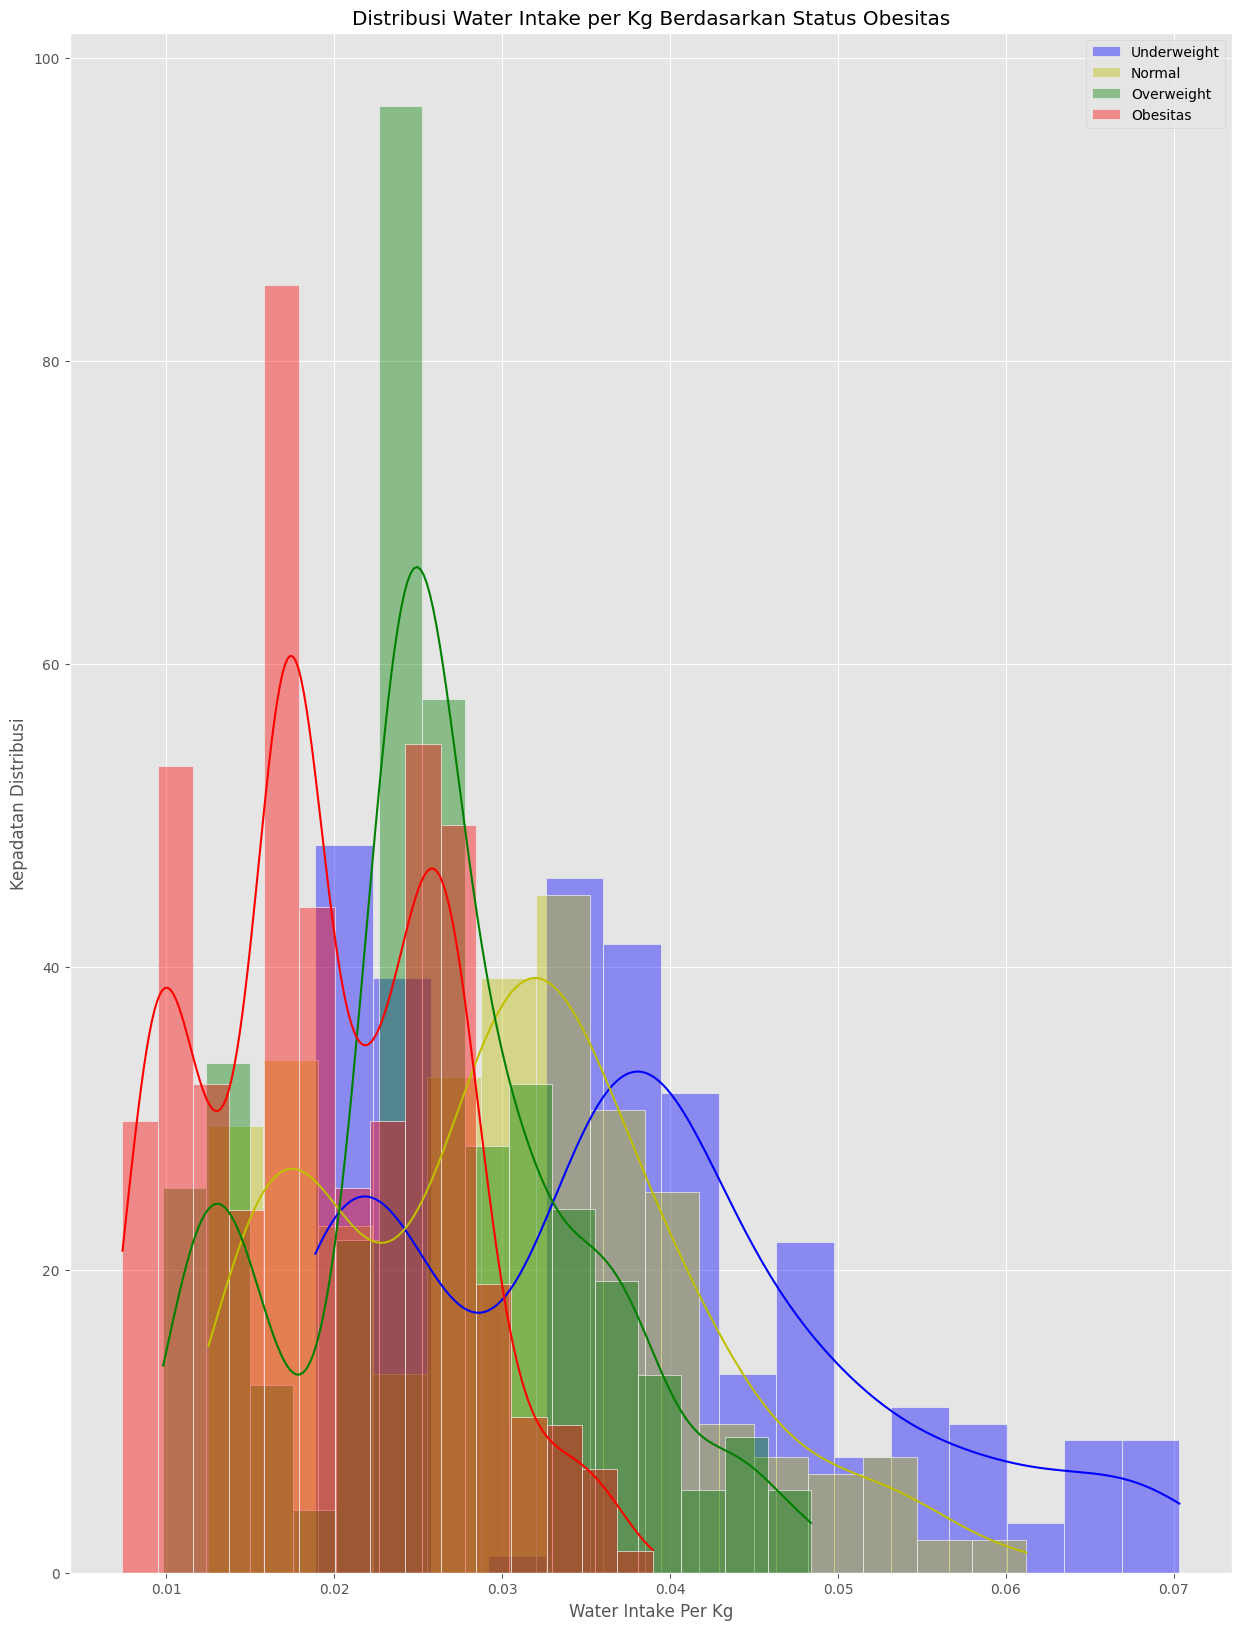

In [18]:


# Ganti distplot jadi histplot, tambah kde=True buat munculin garis kurvanya
# Bins diset ke 15 (jumlah keranjangnya), bukan pakai list rentang yang kebesaran
sns.histplot(df.Water_Intake_Per_Kg[df.Weight_Status == 'Underweight'], bins=15, color="b", label="Underweight", kde=True, stat="density", alpha=0.4)
sns.histplot(df.Water_Intake_Per_Kg[df.Weight_Status == 'Normal'], bins=15, color="y", label="Normal", kde=True, stat="density", alpha=0.4)
sns.histplot(df.Water_Intake_Per_Kg[df.Weight_Status == 'Overweight'], bins=15, color="g", label="Overweight", kde=True, stat="density", alpha=0.4)
sns.histplot(df.Water_Intake_Per_Kg[df.Weight_Status == 'Obesity'], bins=15, color="r", label="Obesitas", kde=True, stat="density", alpha=0.4)

plt.title('Distribusi Water Intake per Kg Berdasarkan Status Obesitas')
plt.xlabel('Water Intake Per Kg')
plt.ylabel('Kepadatan Distribusi')
plt.legend()
plt.show()

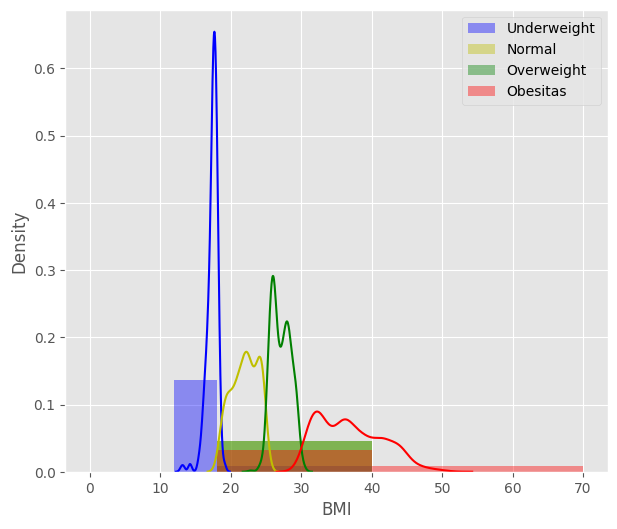

In [19]:
# Hubungan BMI dengan Weight_Status
plt.figure(figsize=(7, 6))
sns.distplot(df.BMI[df.Weight_Status == 'Underweight'], bins=[0, 5, 12, 18, 40, 70], color="b",label="Underweight" )
sns.distplot(df.BMI[df.Weight_Status == 'Normal'], bins=[0, 5, 12, 18, 40, 70], color="y", label="Normal")
sns.distplot(df.BMI[df.Weight_Status == 'Overweight'], bins=[0, 5, 12, 18, 40, 70], color="g", label="Overweight")
sns.distplot(df.BMI[df.Weight_Status == 'Obesity'], bins=[0, 5, 12, 18, 40, 70], color="r", label="Obesitas")
plt.legend()



In [20]:
# Tambahin 'count' buat ngitung jumlah orang di tiap kelas
cek_rentang_bmi = df.groupby('Weight_Status')['BMI'].agg(['count', 'min', 'mean', 'max']).reset_index()

# Urutin dari rata-rata BMI terkecil ke terbesar biar enak dibaca
cek_rentang_bmi = cek_rentang_bmi.sort_values(by='mean')

# Ganti nama kolom biar lebih rapi pas ditampilin di laporan
cek_rentang_bmi.rename(columns={'count': 'Jumlah_Data', 'min': 'BMI_Min', 'mean': 'BMI_Rata2', 'max': 'BMI_Max'}, inplace=True)

print(cek_rentang_bmi)

  Weight_Status  Jumlah_Data  BMI_Min  BMI_Rata2  BMI_Max
3   Underweight          267   12.999     17.391   19.082
0        Normal          282   18.491     22.008   24.913
2    Overweight          566   22.827     27.114   30.363
1       Obesity          972   29.912     36.960   50.812


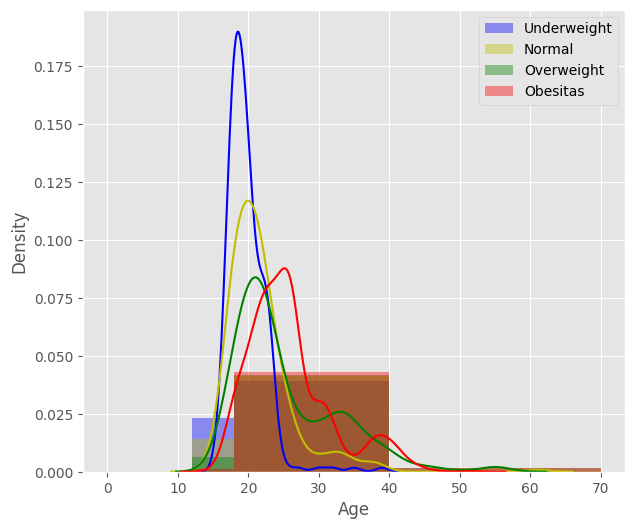

In [21]:
# Hubungan Age dengan Weight_Status
plt.figure(figsize=(7, 6))
sns.distplot(df.Age[df.Weight_Status == 'Underweight'], bins=[0, 5, 12, 18, 40, 70], color="b",label="Underweight" )
sns.distplot(df.Age[df.Weight_Status == 'Normal'], bins=[0, 5, 12, 18, 40, 70], color="y", label="Normal")
sns.distplot(df.Age[df.Weight_Status == 'Overweight'], bins=[0, 5, 12, 18, 40, 70], color="g", label="Overweight")
sns.distplot(df.Age[df.Weight_Status == 'Obesity'], bins=[0, 5, 12, 18, 40, 70], color="r", label="Obesitas")
plt.legend()



*insight*
- Obesity dan Overweight cenderung dialami oleh usia diatas 25 tahun

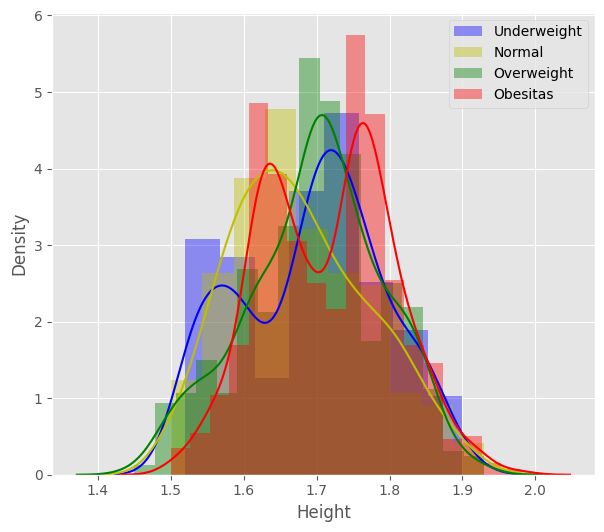

In [22]:
plt.figure(figsize=(7, 6))
sns.distplot(df.Height[df.Weight_Status == 'Underweight'], color="b", label="Underweight")
sns.distplot(df.Height[df.Weight_Status == 'Normal'], color="y", label="Normal")
sns.distplot(df.Height[df.Weight_Status == 'Overweight'], color="g", label="Overweight")
sns.distplot(df.Height[df.Weight_Status == 'Obesity'], color="r", label="Obesitas")
plt.legend()


*Insight*
- Tinggi badan antar kategori Weight_status memiliki distribusi yang cukup mirip.
- Tidak terdapat perbedaan signifikan tinggi badan pada tiap kategori obesitas.

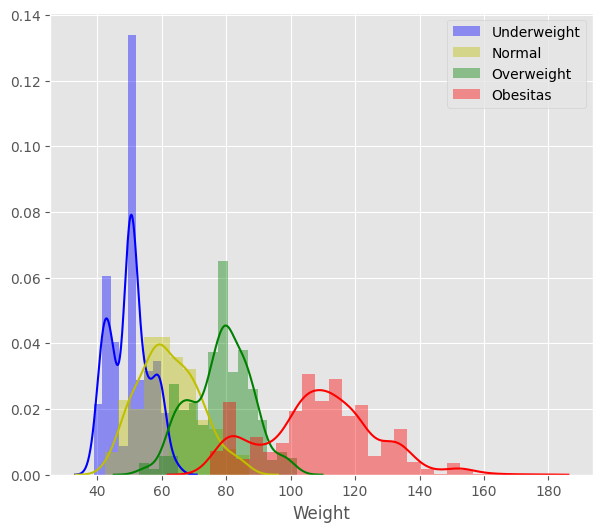

In [23]:
plt.figure(figsize=(7, 6))
sns.distplot(df.Weight[df.Weight_Status == 'Underweight'], color="b", label="Underweight")
sns.distplot(df.Weight[df.Weight_Status == 'Normal'], color="y", label="Normal")
sns.distplot(df.Weight[df.Weight_Status == 'Overweight'], color="g", label="Overweight")
sns.distplot(df.Weight[df.Weight_Status == 'Obesity'], color="r", label="Obesitas")
plt.ylabel('')
plt.legend()



*Insight*
- Kelompok obesitas memiliki berat badan paling tinggi dibanding kategori lain.

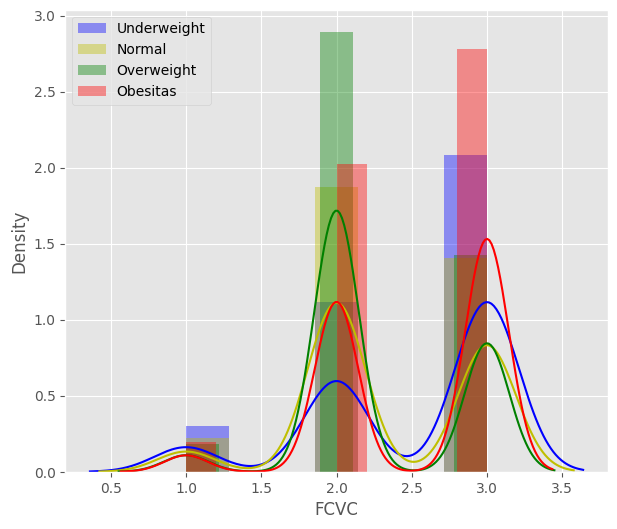

In [24]:
plt.figure(figsize=(7, 6))
sns.distplot(df.FCVC[df.Weight_Status == 'Underweight'], color="b", label="Underweight")
sns.distplot(df.FCVC[df.Weight_Status == 'Normal'], color="y", label="Normal")
sns.distplot(df.FCVC[df.Weight_Status == 'Overweight'], color="g", label="Overweight")
sns.distplot(df.FCVC[df.Weight_Status == 'Obesity'], color="r", label="Obesitas")
plt.legend()



*insight*
- Individu normal dan underweight cenderung memiliki konsumsi sayur lebih tinggi.
- Kelompok obesitas masih muncul pada tingkat konsumsi sayur rendah hingga sedang.

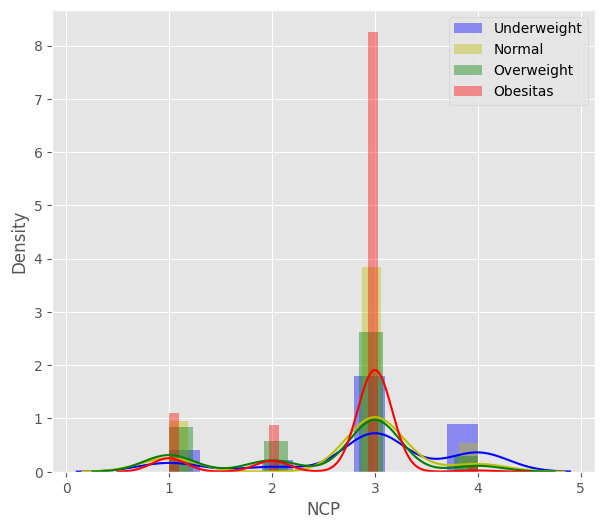

In [25]:
plt.figure(figsize=(7, 6))
sns.distplot(df.NCP[df.Weight_Status == 'Underweight'], color="b", label="Underweight")
sns.distplot(df.NCP[df.Weight_Status == 'Normal'], color="y", label="Normal")
sns.distplot(df.NCP[df.Weight_Status == 'Overweight'], color="g", label="Overweight")
sns.distplot(df.NCP[df.Weight_Status == 'Obesity'], color="r", label="Obesitas")
plt.legend()



*Insight*
- Mayoritas responden mengonsumsi sekitar 3 kali makan utama per hari.

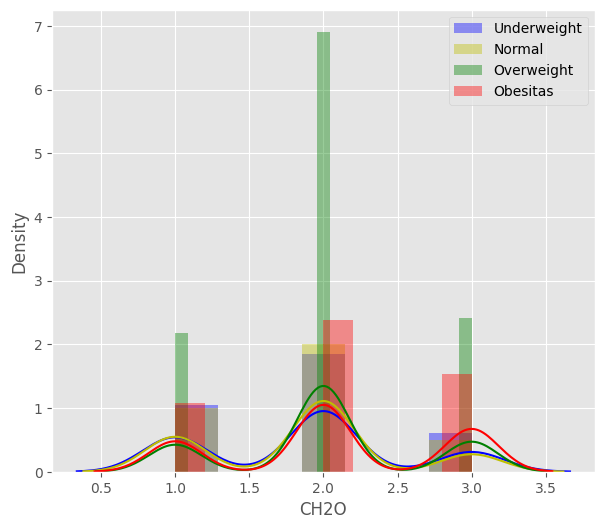

In [26]:
plt.figure(figsize=(7, 6))
sns.distplot(df.CH2O[df.Weight_Status == 'Underweight'], color="b", label="Underweight" )
sns.distplot(df.CH2O[df.Weight_Status == 'Normal'], color="y", label="Normal" )
sns.distplot(df.CH2O[df.Weight_Status == 'Overweight'], color="g", label="Overweight" )
sns.distplot(df.CH2O[df.Weight_Status == 'Obesity'], color="r", label="Obesitas" )
plt.legend()



*Insight*
- Sebagian besar responden berada pada tingkat konsumsi air sedang.
- Tidak terlihat perbedaan yang terlalu ekstrem antar kategori BMI.

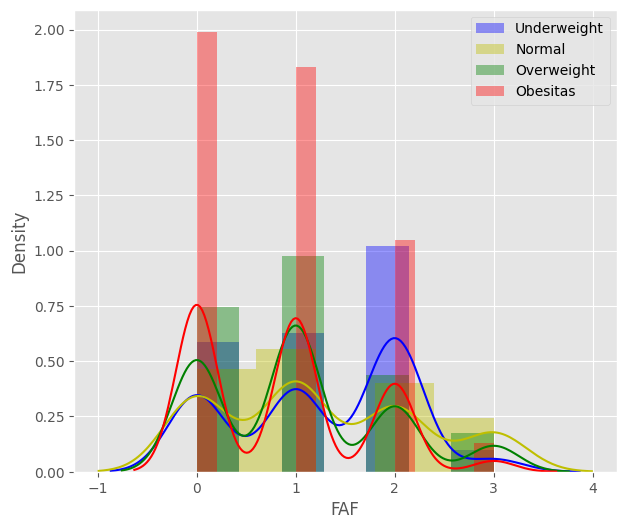

In [27]:
plt.figure(figsize=(7, 6))
sns.distplot(df.FAF[df.Weight_Status == 'Underweight'], color="b", label="Underweight" )
sns.distplot(df.FAF[df.Weight_Status == 'Normal'], color="y", label="Normal")
sns.distplot(df.FAF[df.Weight_Status == 'Overweight'], color="g", label="Overweight")
sns.distplot(df.FAF[df.Weight_Status == 'Obesity'], color="r", label="Obesitas")
plt.legend()



*Insight*
- FAF (Aktivitas Fisik) Untuk status weight nya normal dan underweight frekuensi aktivitas fisik nya lebih banyak dibndingkan status weight yang lain.

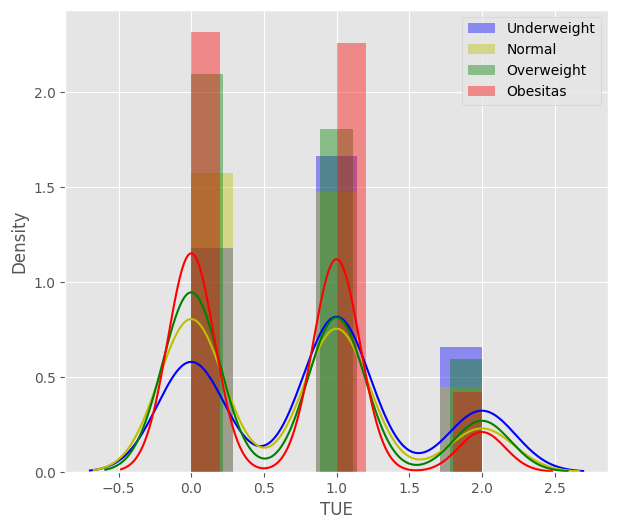

In [28]:
plt.figure(figsize=(7, 6))
sns.distplot(df.TUE[df.Weight_Status == 'Underweight'], color="b", label="Underweight" )
sns.distplot(df.TUE[df.Weight_Status == 'Normal'], color="y", label="Normal")
sns.distplot(df.TUE[df.Weight_Status == 'Overweight'], color="g", label="Overweight")
sns.distplot(df.TUE[df.Weight_Status == 'Obesity'], color="r", label="Obesitas")
plt.legend()



*Insight*
- Kelompok obesitas cenderung memiliki penggunaan teknologi lebih tinggi dibanding kategori lain.
- Individu underweight lebih banyak berada pada durasi penggunaan teknologi rendah.

*Cek Outlier di Fitur numerik*

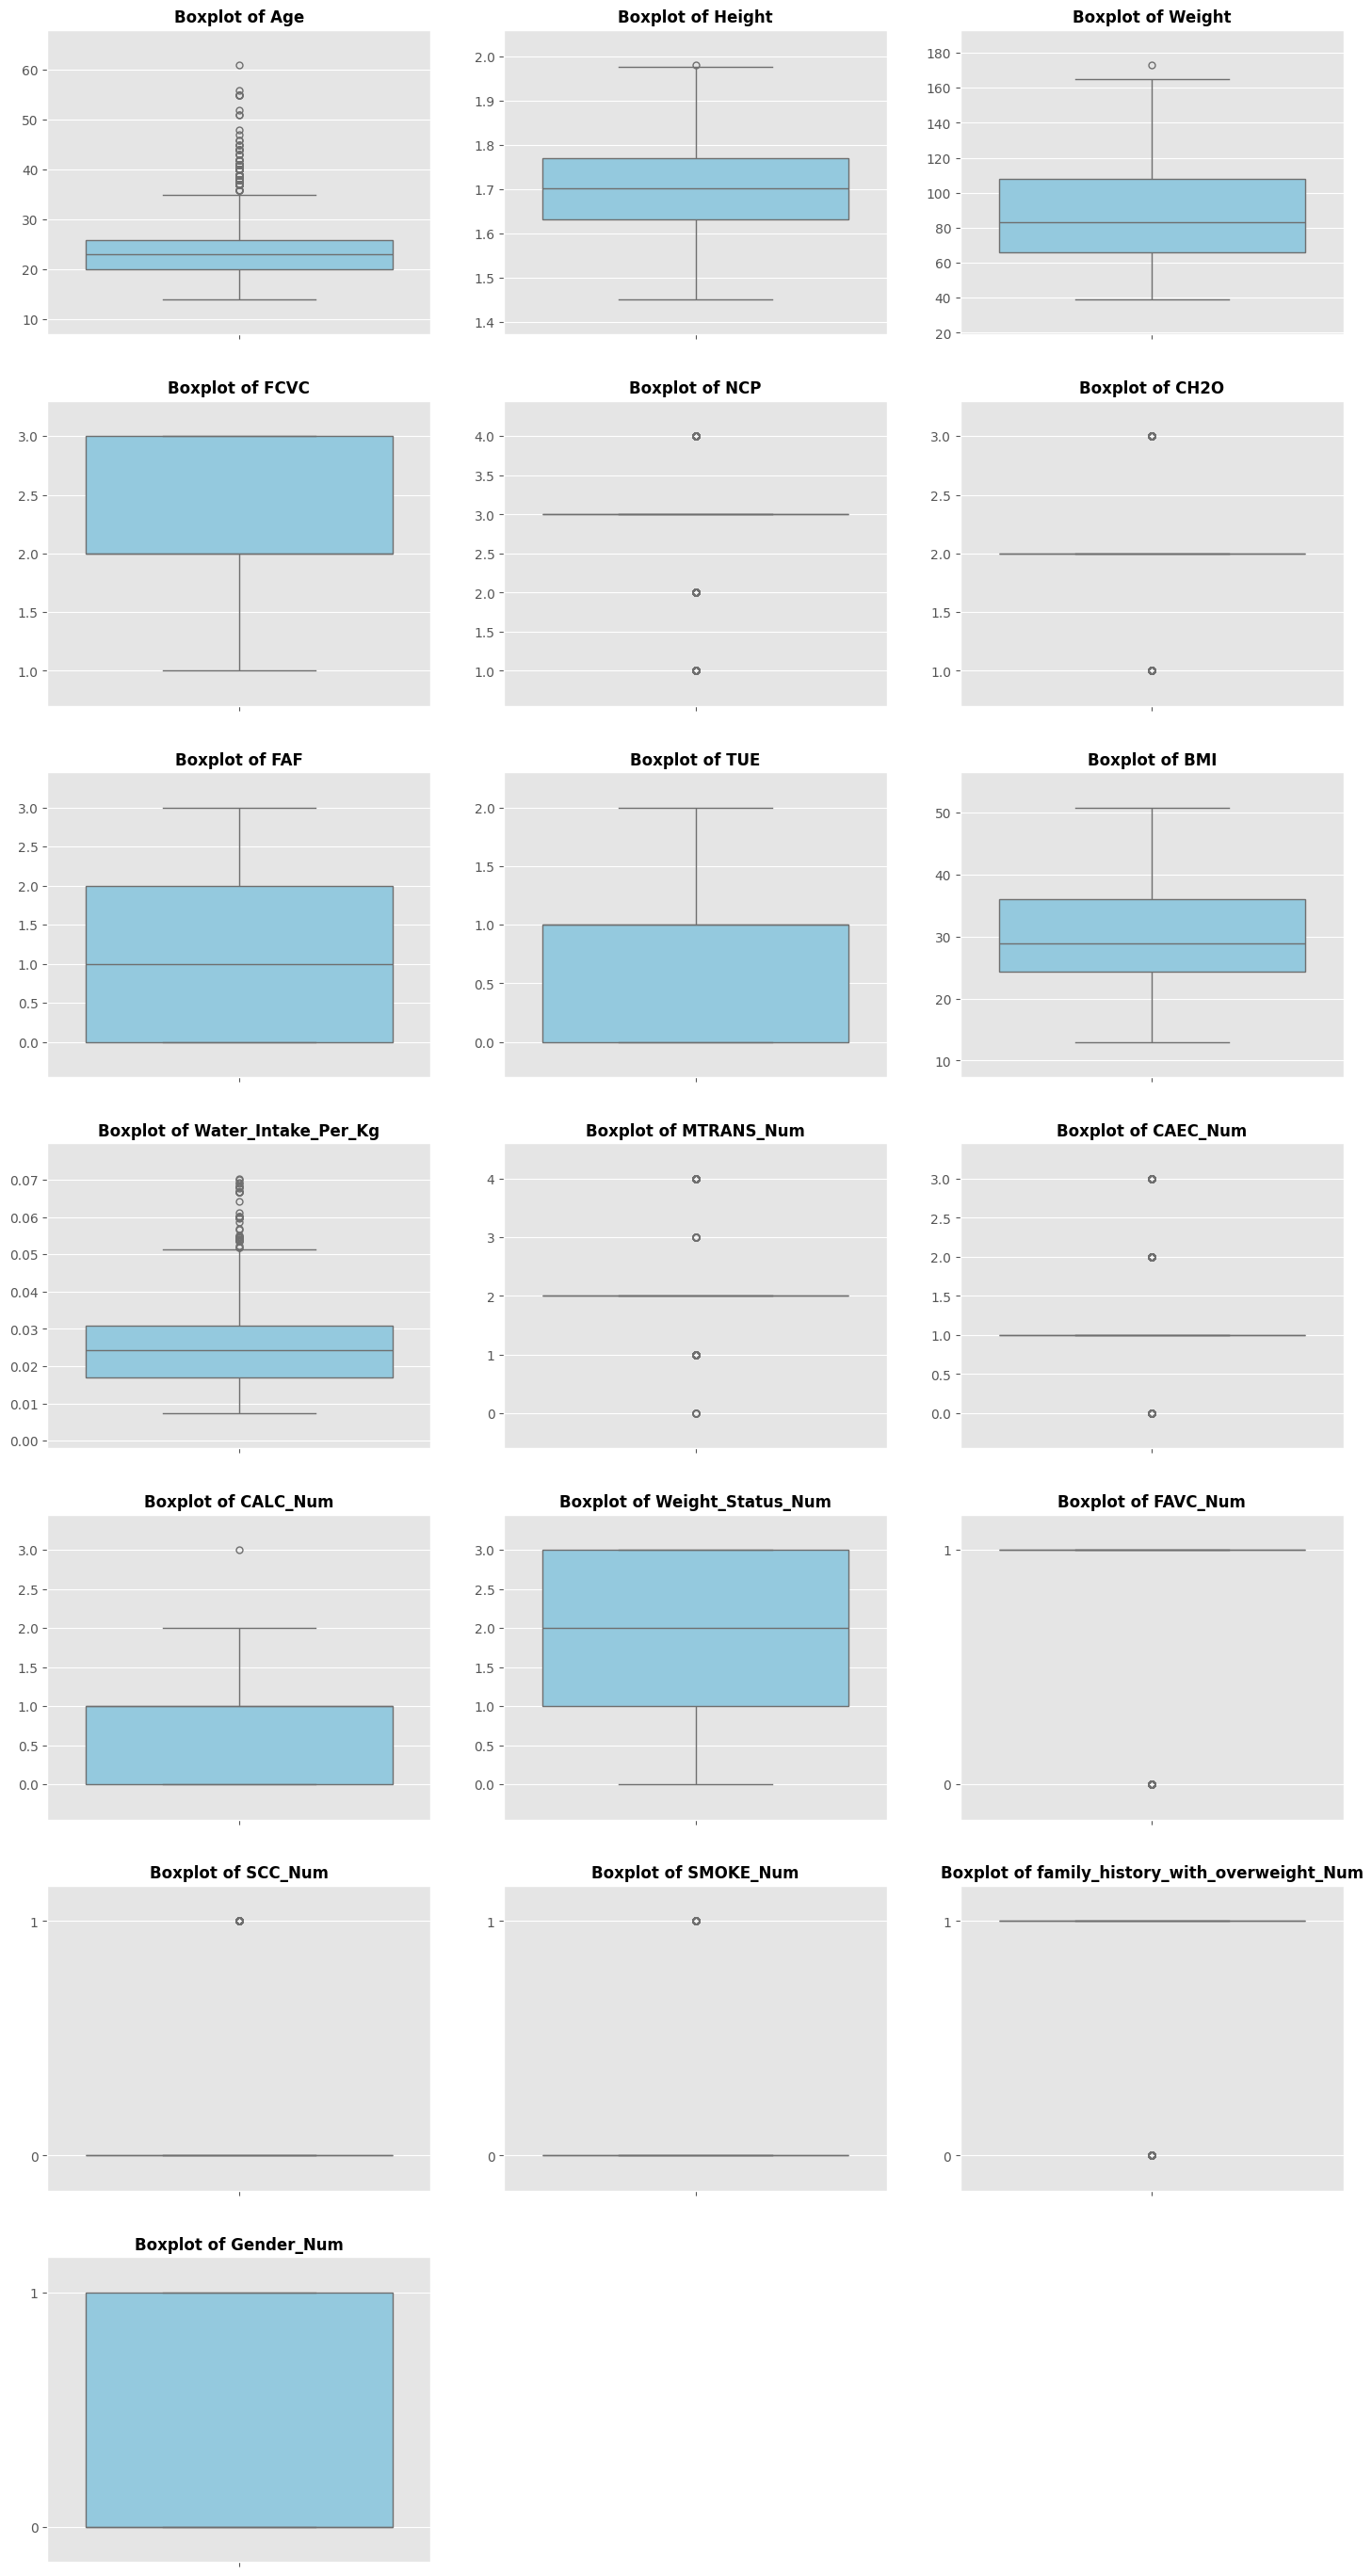

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# 1. Pilih kolom numerik
numeric_cols = df.select_dtypes(include=['int64', 'float64', 'int32']).columns
n_cols = len(numeric_cols)

cols_per_row = 3
rows = math.ceil(n_cols / cols_per_row)

# 2. Atur ukuran kanvas dinamis
plt.figure(figsize=(15, rows * 4))

for i, col in enumerate(numeric_cols, 1):
    ax = plt.subplot(rows, cols_per_row, i)

    # Plot boxplot
    sns.boxplot(y=df[col], color='skyblue', fliersize=5, ax=ax)

    # SET RENTANG Y DINAMIS:
    # Kita ambil nilai min dan max, lalu kasih margin 10% biar nggak nempel garis
    y_min = df[col].min()
    y_max = df[col].max()
    margin = (y_max - y_min) * 0.15 if y_max != y_min else 0.5

    # Set limit Y supaya yang cuma 0-1 nggak kelihatan kayak garis doang
    ax.set_ylim(y_min - margin, y_max + margin)

    # Kalau datanya cuma 0 dan 1 (Binary), kita paksa tick-nya cuma di 0 dan 1
    if y_min == 0 and y_max == 1:
        ax.set_yticks([0, 1])

    plt.title(f'Boxplot of {col}', fontsize=12, fontweight='bold')
    plt.ylabel('')
    plt.tight_layout(pad=3.0)

plt.show()

*Hubungan Fitur Kategorikal dengan Target*

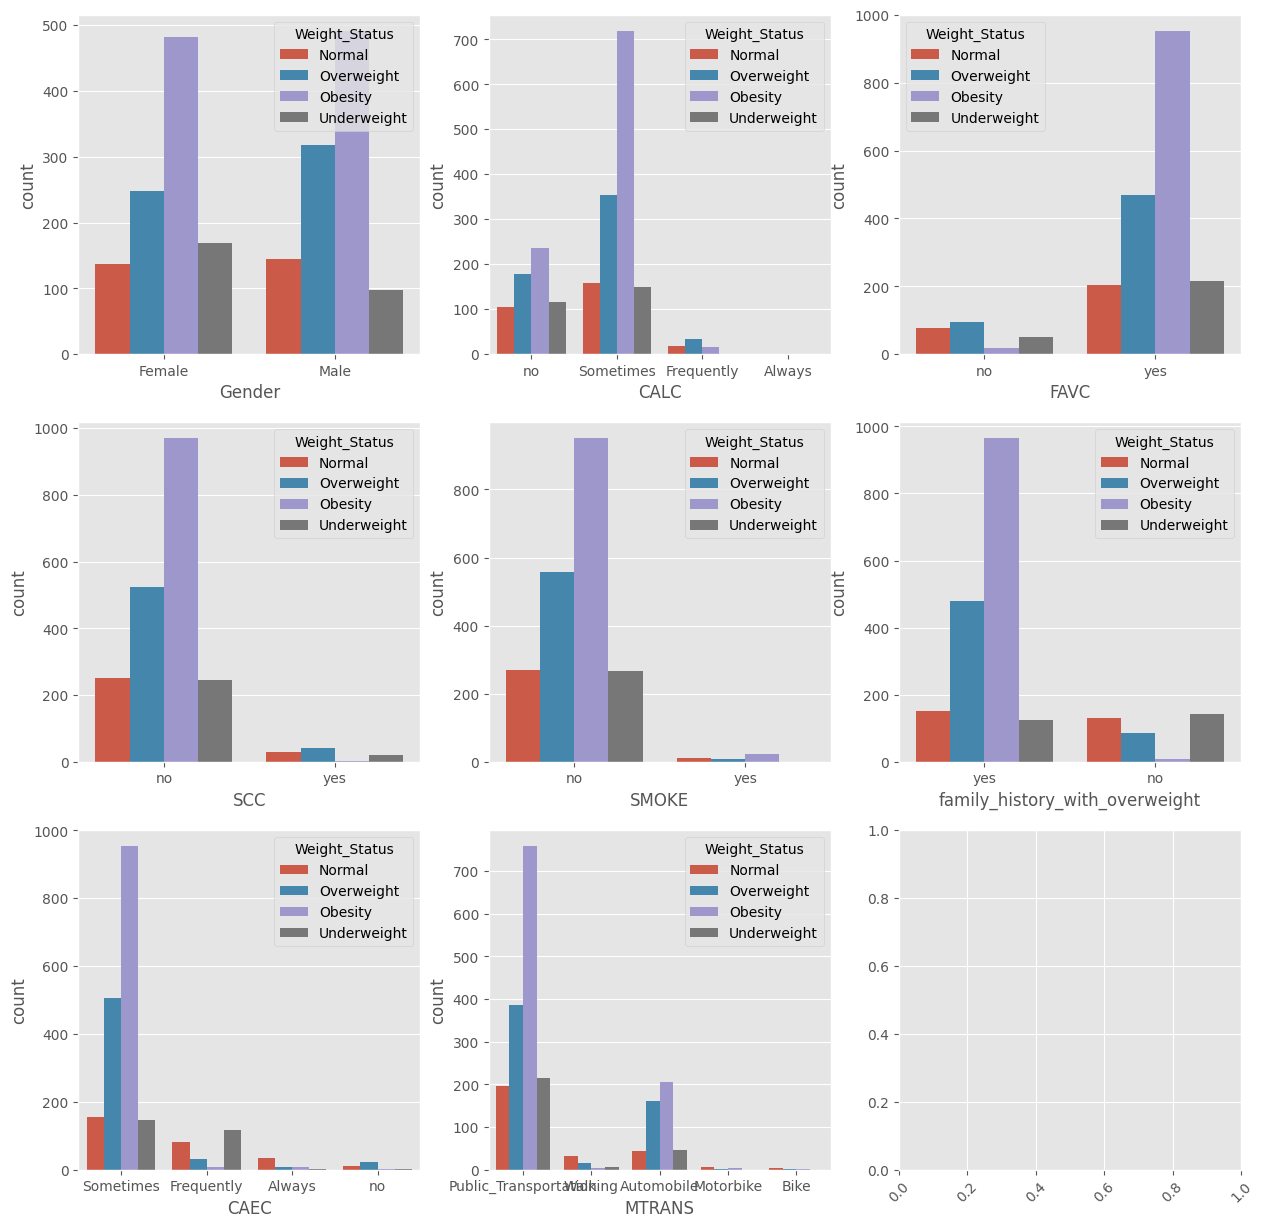

In [30]:
cat_var = ["Gender", "CALC", "FAVC", "SCC", "SMOKE", "family_history_with_overweight", "CAEC", "MTRANS"]

fig, axes = plt.subplots(3,3, figsize=(15,15))
plt.xticks(rotation=45)

for cat, ax in zip(cat_var, axes.flatten()):
    sns.countplot(x=cat, data=df, hue="Weight_Status", ax=ax)

*Insight*
- Konsumsi makanan tinggi kalori (FAVC) terlihat lebih sering muncul pada kategori obesitas.
- Frekuensi konsumsi sayur (FCVC) yang rendah cenderung lebih banyak pada kelompok obesitas.
- Kebiasaan merokok (SMOKE) tidak menunjukkan pengaruh yang terlalu besar terhadap obesitas pada dataset ini.
- Penggunaan transportasi (MTRANS) memperlihatkan bahwa individu yang lebih pasif cenderung berada di kategori overweight/obesitas.

*Analisis Korelasi*

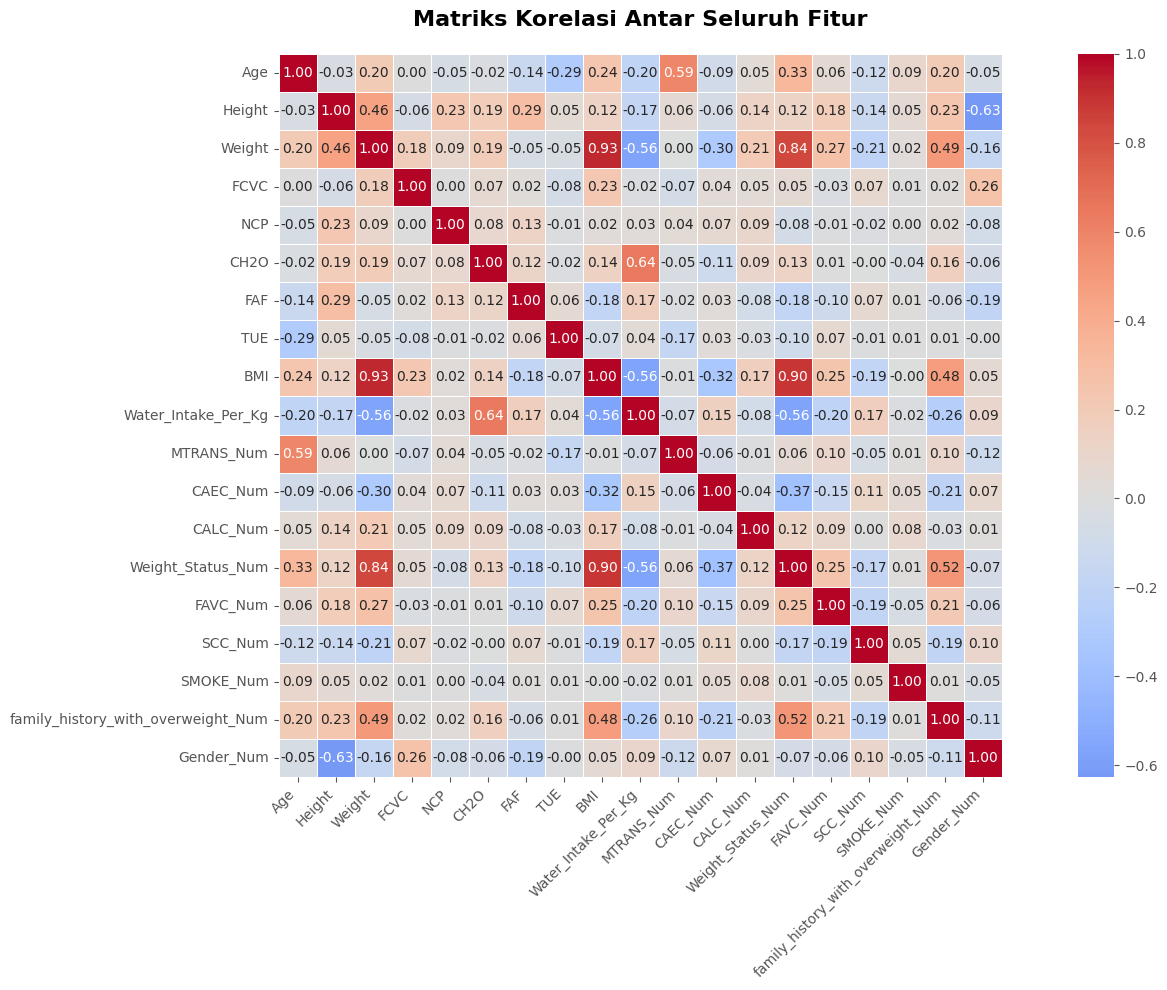

In [31]:
# --- 4. VISUALISASI KORELASI ANTAR FITUR ---
# Hitung matriks korelasi hanya untuk kolom numerik
fitur_angka = df.select_dtypes(include=['number']).columns
corr_matrix = df[fitur_angka].corr()

plt.figure(figsize=(16, 10))

# Membuat heatmap kotak penuh
sns.heatmap(corr_matrix,
            annot=True,
            fmt=".2f",
            cmap='coolwarm',
            center=0,
            linewidths=0.5,
            square=True) # Menjaga bentuk sel tetap kotak

plt.title('Matriks Korelasi Antar Seluruh Fitur', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

*Insight*
- Weight memiliki korelasi paling tinggi terhadap obesitas, sehingga berat badan menjadi faktor utama dalam klasifikasi obesitas.
- Height dan Weight memiliki korelasi positif sedang, artinya semakin tinggi seseorang biasanya berat badannya juga meningkat.
- Age memiliki korelasi negatif terhadap TUE (penggunaan teknologi), menunjukkan usia lebih muda cenderung lebih sering menggunakan perangkat teknologi.

*Cek Outlier di Fitur numerik*

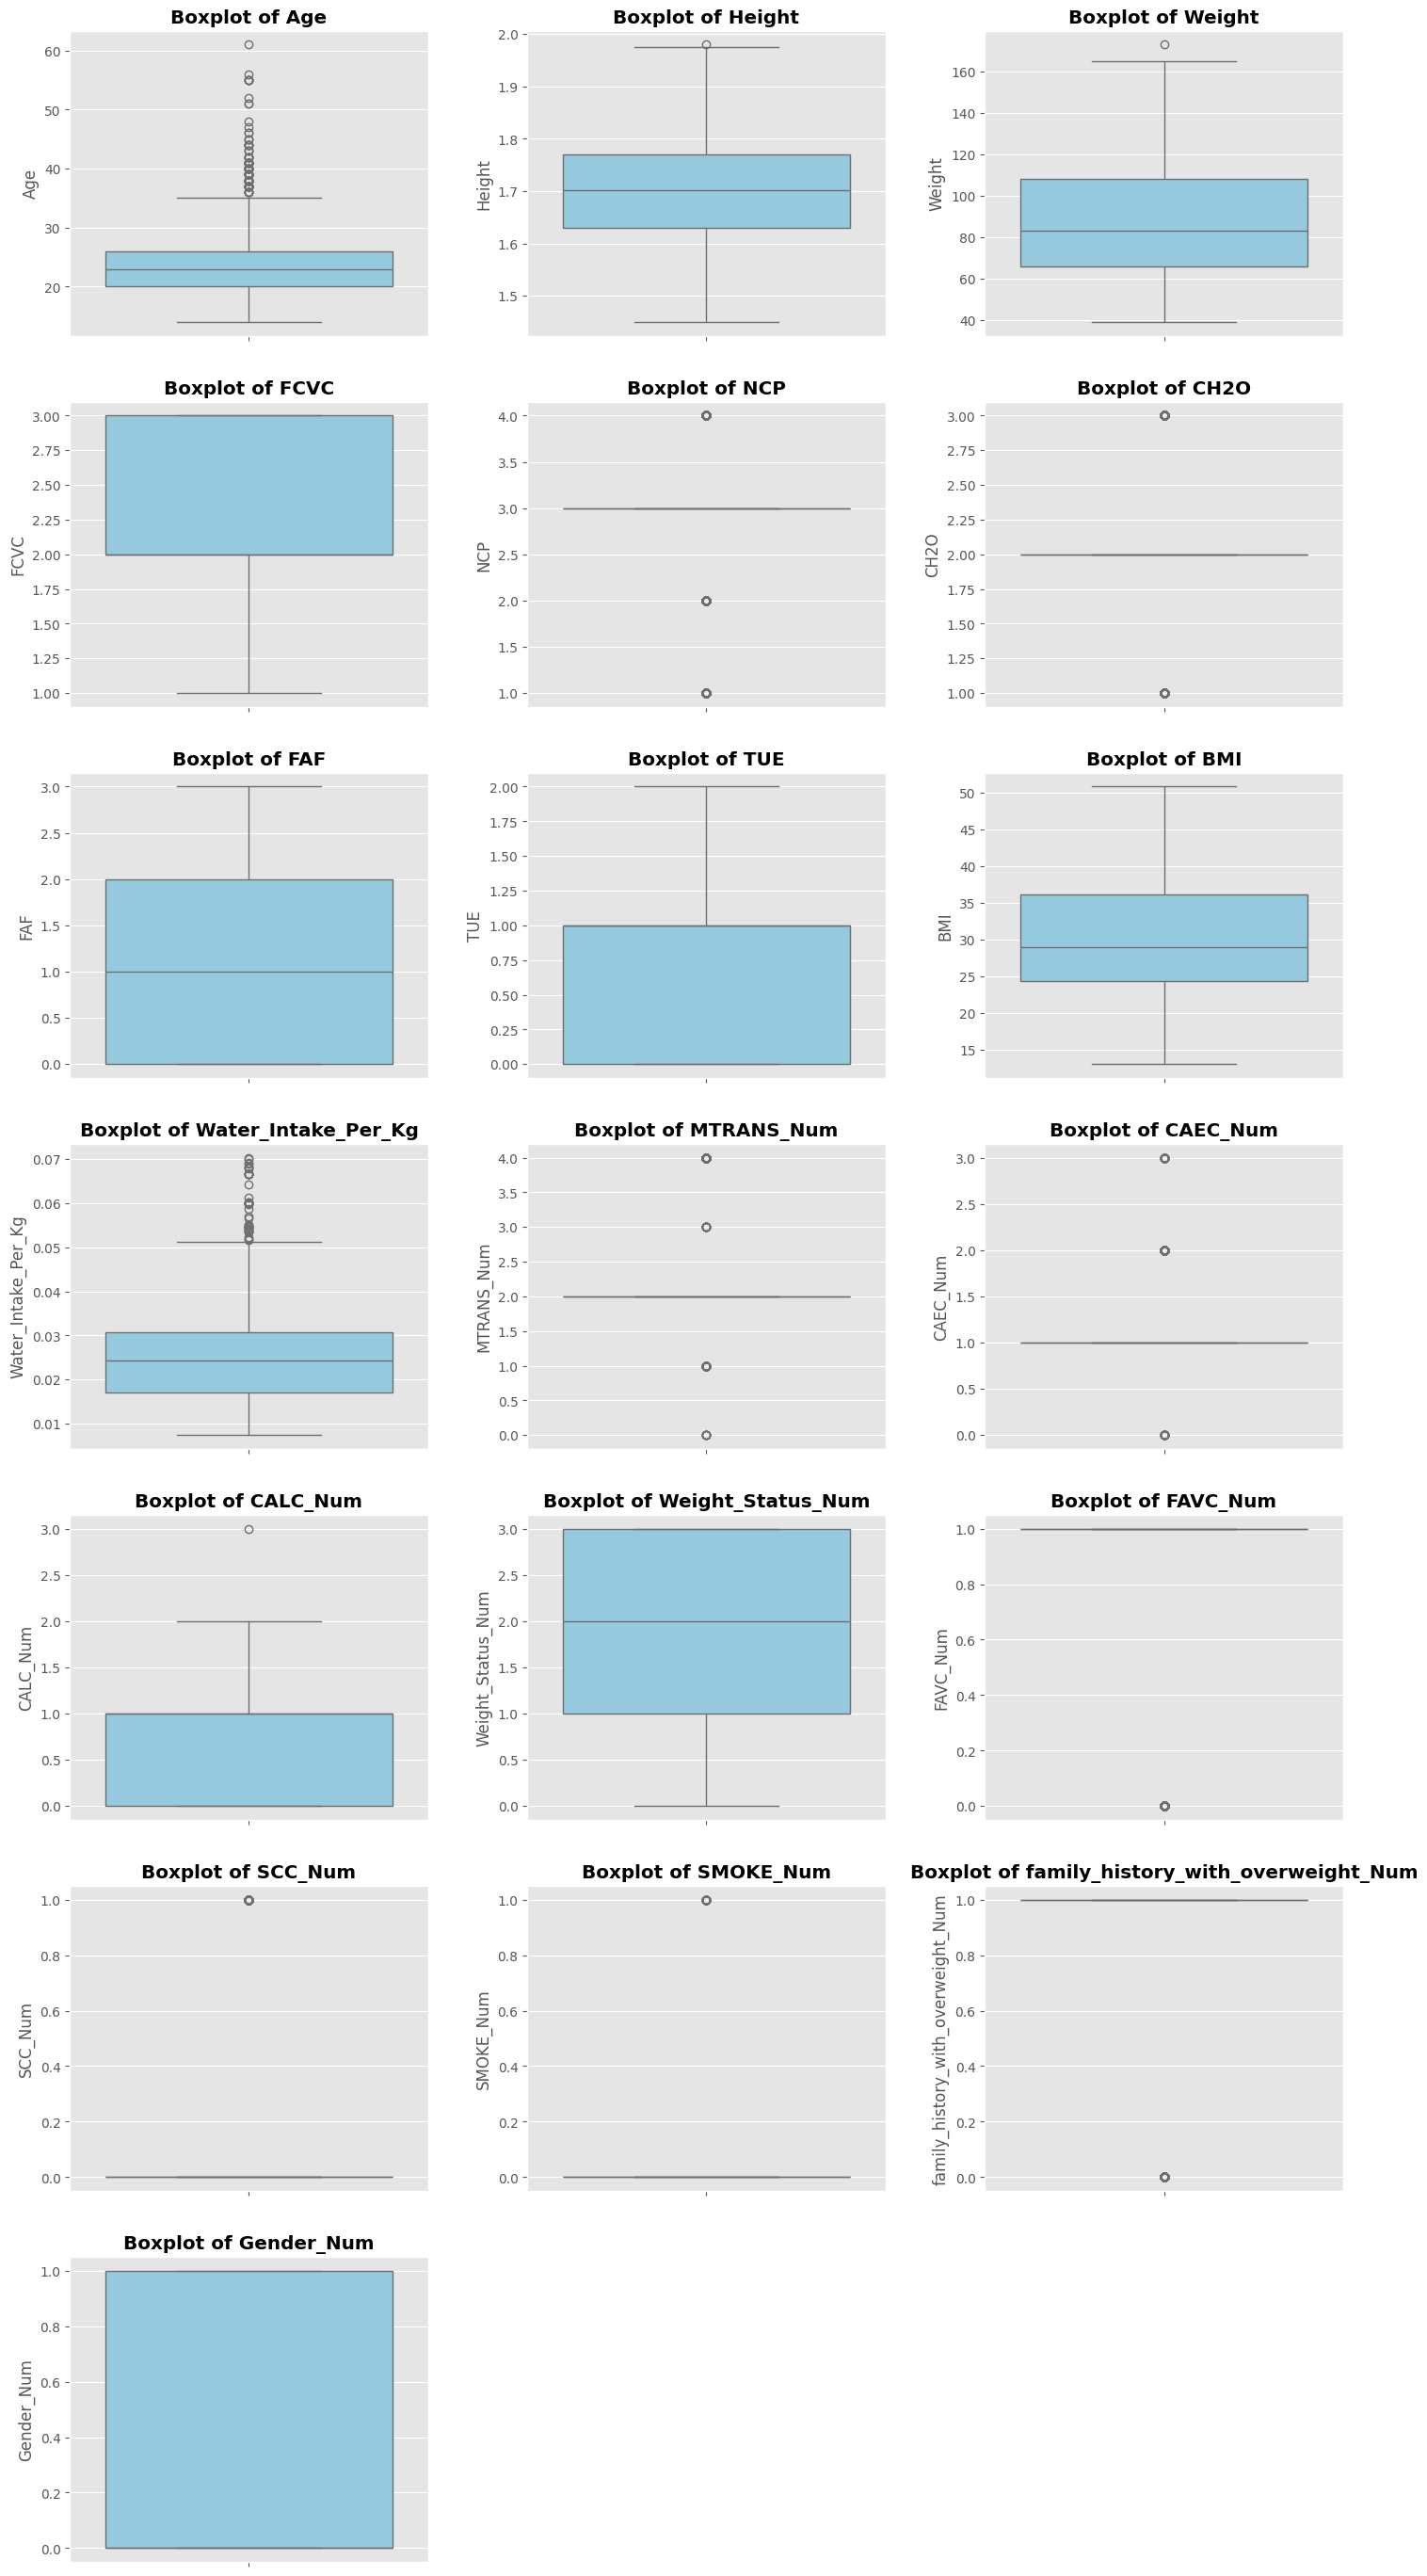

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# 1. Pilih kolom numerik (termasuk hasil encoding int32/int64)
numeric_cols = df.select_dtypes(include=['number']).columns
n_cols = len(numeric_cols)

# 2. Tentukan grid (3 kolom per baris)
cols_per_row = 3
rows = math.ceil(n_cols / cols_per_row)

# 3. Atur ukuran kanvas secara DINAMIS (Tinggi = jumlah baris x 4 unit)
plt.figure(figsize=(15, rows * 4))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(rows, cols_per_row, i)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(f'Boxplot of {col}', fontweight='bold')
    plt.tight_layout(pad=3.0) # Memberikan jarak antar subplot agar judul tidak tabrakan

plt.show()

# Data Visualization & Explanatory


Pertanyaan 1 : Bagaimana Distribusi Data Kolom Weight_Status Sebagai Target ?

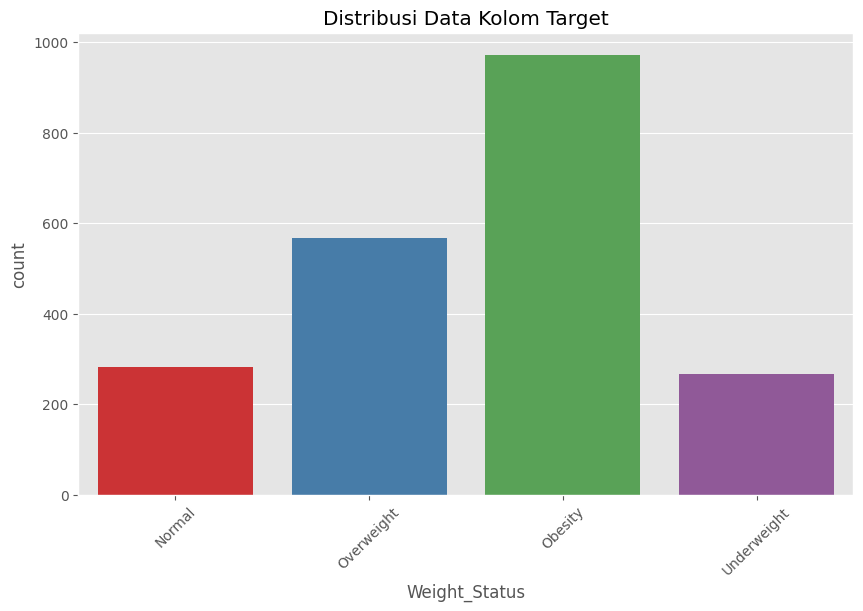

In [33]:
# Distribution of the target variable
plt.figure(figsize=(10, 6))
sns.countplot(x='Weight_Status', data=df, palette='Set1')
plt.title('Distribusi Data Kolom Target')
plt.xticks(rotation=45)
plt.show()

Pertanyaan 2: Hubungan Antara Usia dengan Weight_Status

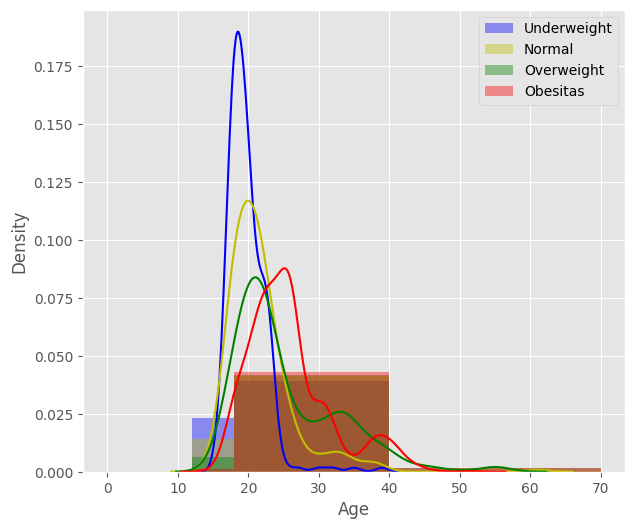

In [34]:
# Hubungan Age dengan Weight_Status
plt.figure(figsize=(7, 6))
sns.distplot(df.Age[df.Weight_Status == 'Underweight'], bins=[0, 5, 12, 18, 40, 70], color="b",label="Underweight" )
sns.distplot(df.Age[df.Weight_Status == 'Normal'], bins=[0, 5, 12, 18, 40, 70], color="y", label="Normal")
sns.distplot(df.Age[df.Weight_Status == 'Overweight'], bins=[0, 5, 12, 18, 40, 70], color="g", label="Overweight")
sns.distplot(df.Age[df.Weight_Status == 'Obesity'], bins=[0, 5, 12, 18, 40, 70], color="r", label="Obesitas")
plt.legend()



Dari visualisasi tersebut dapat dilihat bahwa obesitas dapat dialami oleh usia di atas 25 tahun

Pertanyaan 3: Apa Fitur yang Paling Signifikan dengan Target ?

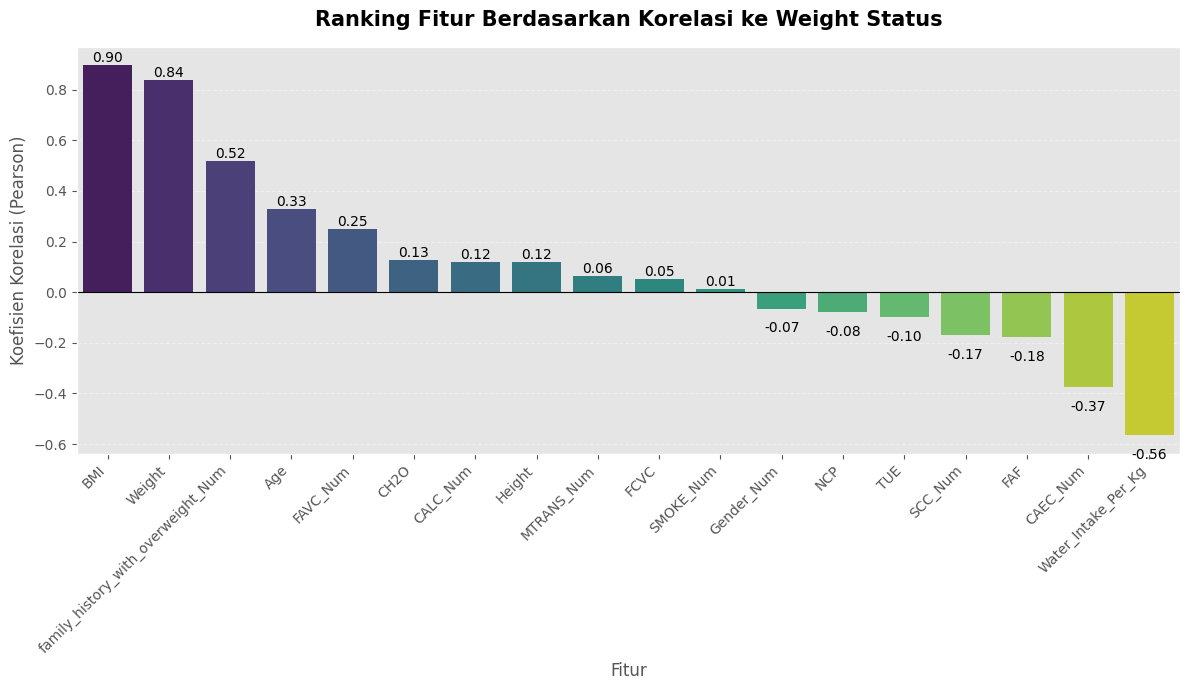

In [35]:
# --- 5. BAR PLOT KORELASI TERHADAP TARGET ---
# Ambil korelasi spesifik ke target, hapus baris target itu sendiri, dan urutkan
target_corr = corr_matrix['Weight_Status_Num'].drop('Weight_Status_Num').sort_values(ascending=False)

plt.figure(figsize=(12, 7))

# Plotting
sns.barplot(x=target_corr.index,
            y=target_corr.values,
            hue=target_corr.index,
            palette='viridis',
            legend=False)

# Tambahan garis bantu di y=0
plt.axhline(0, color='black', linewidth=0.8)

plt.title('Ranking Fitur Berdasarkan Korelasi ke Weight Status', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Fitur', fontsize=12)
plt.ylabel('Koefisien Korelasi (Pearson)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.4)

# Tambahkan label nilai di atas bar (opsional tapi sangat membantu)
for i, v in enumerate(target_corr.values):
    plt.text(i, v if v > 0 else v - 0.05, f'{v:.2f}', ha='center', va='bottom' if v > 0 else 'top', fontsize=10)

plt.tight_layout()
plt.show()

*Insight*

3 Fitur paling Signifikan dengan Target Ialah Weight, family_history_with_overweight dan Age


## Splitting Data

In [36]:
from sklearn.model_selection import train_test_split

# Split data utama jadi train dan test dengan proporsi 80:20
df_train, df_test = train_test_split(df, test_size=0.2, random_state=42, stratify=df['Weight_Status'])

# Drop kolom target di df_test biar murni jadi data buat ujian
df_test.drop(columns=['Weight_Status'], inplace=True)

# Cek hasil split
print(f"Dimensi df_train: {df_train.shape}")
print(f"Dimensi df_test : {df_test.shape}")
print("=" * 50)

# Cek hasil splitting
print("Kolom di df_train:")
print(df_train.columns.tolist())
print("=" * 50)
print("Kolom di df_test:")
print(df_test.columns.tolist())

Dimensi df_train: (1669, 28)
Dimensi df_test : (418, 27)
Kolom di df_train:
['Age', 'Gender', 'Height', 'Weight', 'CALC', 'FAVC', 'FCVC', 'NCP', 'SCC', 'SMOKE', 'CH2O', 'family_history_with_overweight', 'FAF', 'TUE', 'CAEC', 'MTRANS', 'Weight_Status', 'BMI', 'Water_Intake_Per_Kg', 'MTRANS_Num', 'CAEC_Num', 'CALC_Num', 'Weight_Status_Num', 'FAVC_Num', 'SCC_Num', 'SMOKE_Num', 'family_history_with_overweight_Num', 'Gender_Num']
Kolom di df_test:
['Age', 'Gender', 'Height', 'Weight', 'CALC', 'FAVC', 'FCVC', 'NCP', 'SCC', 'SMOKE', 'CH2O', 'family_history_with_overweight', 'FAF', 'TUE', 'CAEC', 'MTRANS', 'BMI', 'Water_Intake_Per_Kg', 'MTRANS_Num', 'CAEC_Num', 'CALC_Num', 'Weight_Status_Num', 'FAVC_Num', 'SCC_Num', 'SMOKE_Num', 'family_history_with_overweight_Num', 'Gender_Num']


## Data Transformation

### Feature Selection

In [37]:
# 1. Tentukan list fitur yang akan dipertahankan (tanpa target untuk test set)
features_to_keep = [
    'Age', 'BMI', 'Water_Intake_Per_Kg', 'FAF',
    'Gender_Num', 'family_history_with_overweight_Num', 'CAEC_Num',
    'FAVC_Num', 'SCC_Num'
]

# 2. Filter df_train (Pertahankan Fitur + Target)
# Kita butuh 'Weight_Status_Num' di train untuk proses belajar model
df_train = df_train[features_to_keep + ['Weight_Status_Num']].copy()

# 3. Filter df_test (Hanya Fitur)
# Kita hanya menyisakan fitur agar formatnya sama dengan input user nanti
df_test = df_test[features_to_keep].copy()

# --- VERIFIKASI AKHIR ---
print("✅ Seleksi Fitur Berhasil!")
print(f"Dimensi df_train: {df_train.shape} (9 Fitur + 1 Target)")
print(f"Dimensi df_test : {df_test.shape} (9 Fitur)")
print("-" * 30)
print("Fitur yang digunakan untuk pelatihan & input user:")
print(df_test.columns.tolist())

✅ Seleksi Fitur Berhasil!
Dimensi df_train: (1669, 10) (9 Fitur + 1 Target)
Dimensi df_test : (418, 9) (9 Fitur)
------------------------------
Fitur yang digunakan untuk pelatihan & input user:
['Age', 'BMI', 'Water_Intake_Per_Kg', 'FAF', 'Gender_Num', 'family_history_with_overweight_Num', 'CAEC_Num', 'FAVC_Num', 'SCC_Num']


In [38]:
df_train

,Age,BMI,Water_Intake_Per_Kg,FAF,Gender_Num,family_history_with_overweight_Num,CAEC_Num,FAVC_Num,SCC_Num,Weight_Status_Num
1401,39,33.014,0.013,0,1,1,1.0,1,0,3.0
2087,26,41.910,0.027,0,1,1,1.0,1,0,3.0
1324,22,31.988,0.024,0,1,1,1.0,1,0,3.0
664,22,17.906,0.039,0,1,1,2.0,1,0,0.0
835,29,25.912,0.029,2,1,1,1.0,1,0,2.0
...,...,...,...,...,...,...,...,...,...,...
2056,26,41.695,0.027,0,1,1,1.0,1,0,3.0
771,23,25.705,0.026,0,1,1,2.0,1,0,2.0
201,41,33.733,0.013,0,1,1,3.0,1,0,3.0
1765,31,37.498,0.016,1,0,1,1.0,1,0,3.0


In [39]:
df_test

,Age,BMI,Water_Intake_Per_Kg,FAF,Gender_Num,family_history_with_overweight_Num,CAEC_Num,FAVC_Num,SCC_Num
598,18,17.554,0.039,0,0,1,1.0,1,0
780,20,26.058,0.024,1,0,1,1.0,1,0
1772,25,36.839,0.017,1,0,1,1.0,1,0
2010,26,40.144,0.010,0,1,1,1.0,1,0
311,17,20.957,0.032,3,0,0,3.0,1,0
...,...,...,...,...,...,...,...,...,...
123,24,24.314,0.030,1,0,1,1.0,1,0
1263,38,30.830,0.025,2,1,1,1.0,1,0
384,18,23.437,0.017,0,1,1,1.0,1,1
874,16,25.970,0.029,1,1,1,1.0,1,0


### Normalization

In [40]:
from sklearn.preprocessing import QuantileTransformer
import joblib
import pandas as pd

scaler = QuantileTransformer(output_distribution='normal', random_state=42)

# Fitur yang diproses (Kontinu)
columns_to_scale = ['Age', 'BMI', 'Water_Intake_Per_Kg']

# Fitur yang dibiarkan murni (Diskrit/Kategori)
unscaled_features = [
    'Gender_Num', 'FAF', 'family_history_with_overweight_Num',
    'FAVC_Num', 'SCC_Num', 'CAEC_Num'
]

# Eksekusi Scaling
df_train_scaled = df_train.copy()
df_train_scaled[columns_to_scale] = scaler.fit_transform(df_train[columns_to_scale])

df_test_scaled = df_test.copy()
df_test_scaled[columns_to_scale] = scaler.transform(df_test[columns_to_scale])

# Cek nilai unik semua fitur yang TIDAK di-scale
print("--- NILAI UNIK FITUR NON-SCALE (df_train_scaled) ---")
for col in unscaled_features:
    if col in df_train_scaled.columns:
        print(f"{col}: {sorted(df_train_scaled[col].unique())}")

# Simpan scaler
joblib.dump(scaler, 'scaler_obesitas.pkl')

print("\n✅ Scaler sudah diterapkan ke dataset dan berhasil disimpan!")

--- NILAI UNIK FITUR NON-SCALE (df_train_scaled) ---
Gender_Num: [np.int64(0), np.int64(1)]
FAF: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
family_history_with_overweight_Num: [np.int64(0), np.int64(1)]
FAVC_Num: [np.int64(0), np.int64(1)]
SCC_Num: [np.int64(0), np.int64(1)]
CAEC_Num: [np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0)]

✅ Scaler sudah diterapkan ke dataset dan berhasil disimpan!


In [41]:
df_train_scaled.describe()

,Age,BMI,Water_Intake_Per_Kg,FAF,Gender_Num,family_history_with_overweight_Num,CAEC_Num,FAVC_Num,SCC_Num,Weight_Status_Num
count,1669.000,1.669e+03,1.669e+03,1669.000,1669.000,1669.000,1669.000,1669.000,1669.000,1669.000
mean,0.004,-8.063e-05,-7.316e-05,1.029,0.493,0.828,1.140,0.886,0.044,2.074
std,1.001,1.012e+00,1.012e+00,0.904,0.500,0.377,0.454,0.318,0.206,1.053
min,-5.199,-5.199e+00,-5.199e+00,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,-0.641,-6.746e-01,-6.737e-01,0.000,0.000,1.000,1.000,1.000,0.000,1.000
50%,0.069,5.532e-04,-5.133e-04,1.000,0.000,1.000,1.000,1.000,0.000,2.000
75%,0.572,6.740e-01,6.738e-01,2.000,1.000,1.000,1.000,1.000,0.000,3.000
max,5.199,5.199e+00,5.199e+00,3.000,1.000,1.000,3.000,1.000,1.000,3.000


In [42]:
df_test_scaled.describe()

,Age,BMI,Water_Intake_Per_Kg,FAF,Gender_Num,family_history_with_overweight_Num,CAEC_Num,FAVC_Num,SCC_Num
count,418.000,418.000,418.000,418.000,418.000,418.000,418.000,418.000,418.000
mean,-0.011,-0.005,0.048,0.931,0.507,0.813,1.172,0.876,0.053
std,0.991,0.973,1.040,0.875,0.501,0.390,0.479,0.330,0.224
min,-2.575,-2.242,-3.051,0.000,0.000,0.000,0.000,0.000,0.000
25%,-0.641,-0.677,-0.607,0.000,0.000,1.000,1.000,1.000,0.000
50%,0.069,-0.052,0.074,1.000,1.000,1.000,1.000,1.000,0.000
75%,0.572,0.647,0.753,2.000,1.000,1.000,1.000,1.000,0.000
max,2.878,2.738,5.199,3.000,1.000,1.000,3.000,1.000,1.000


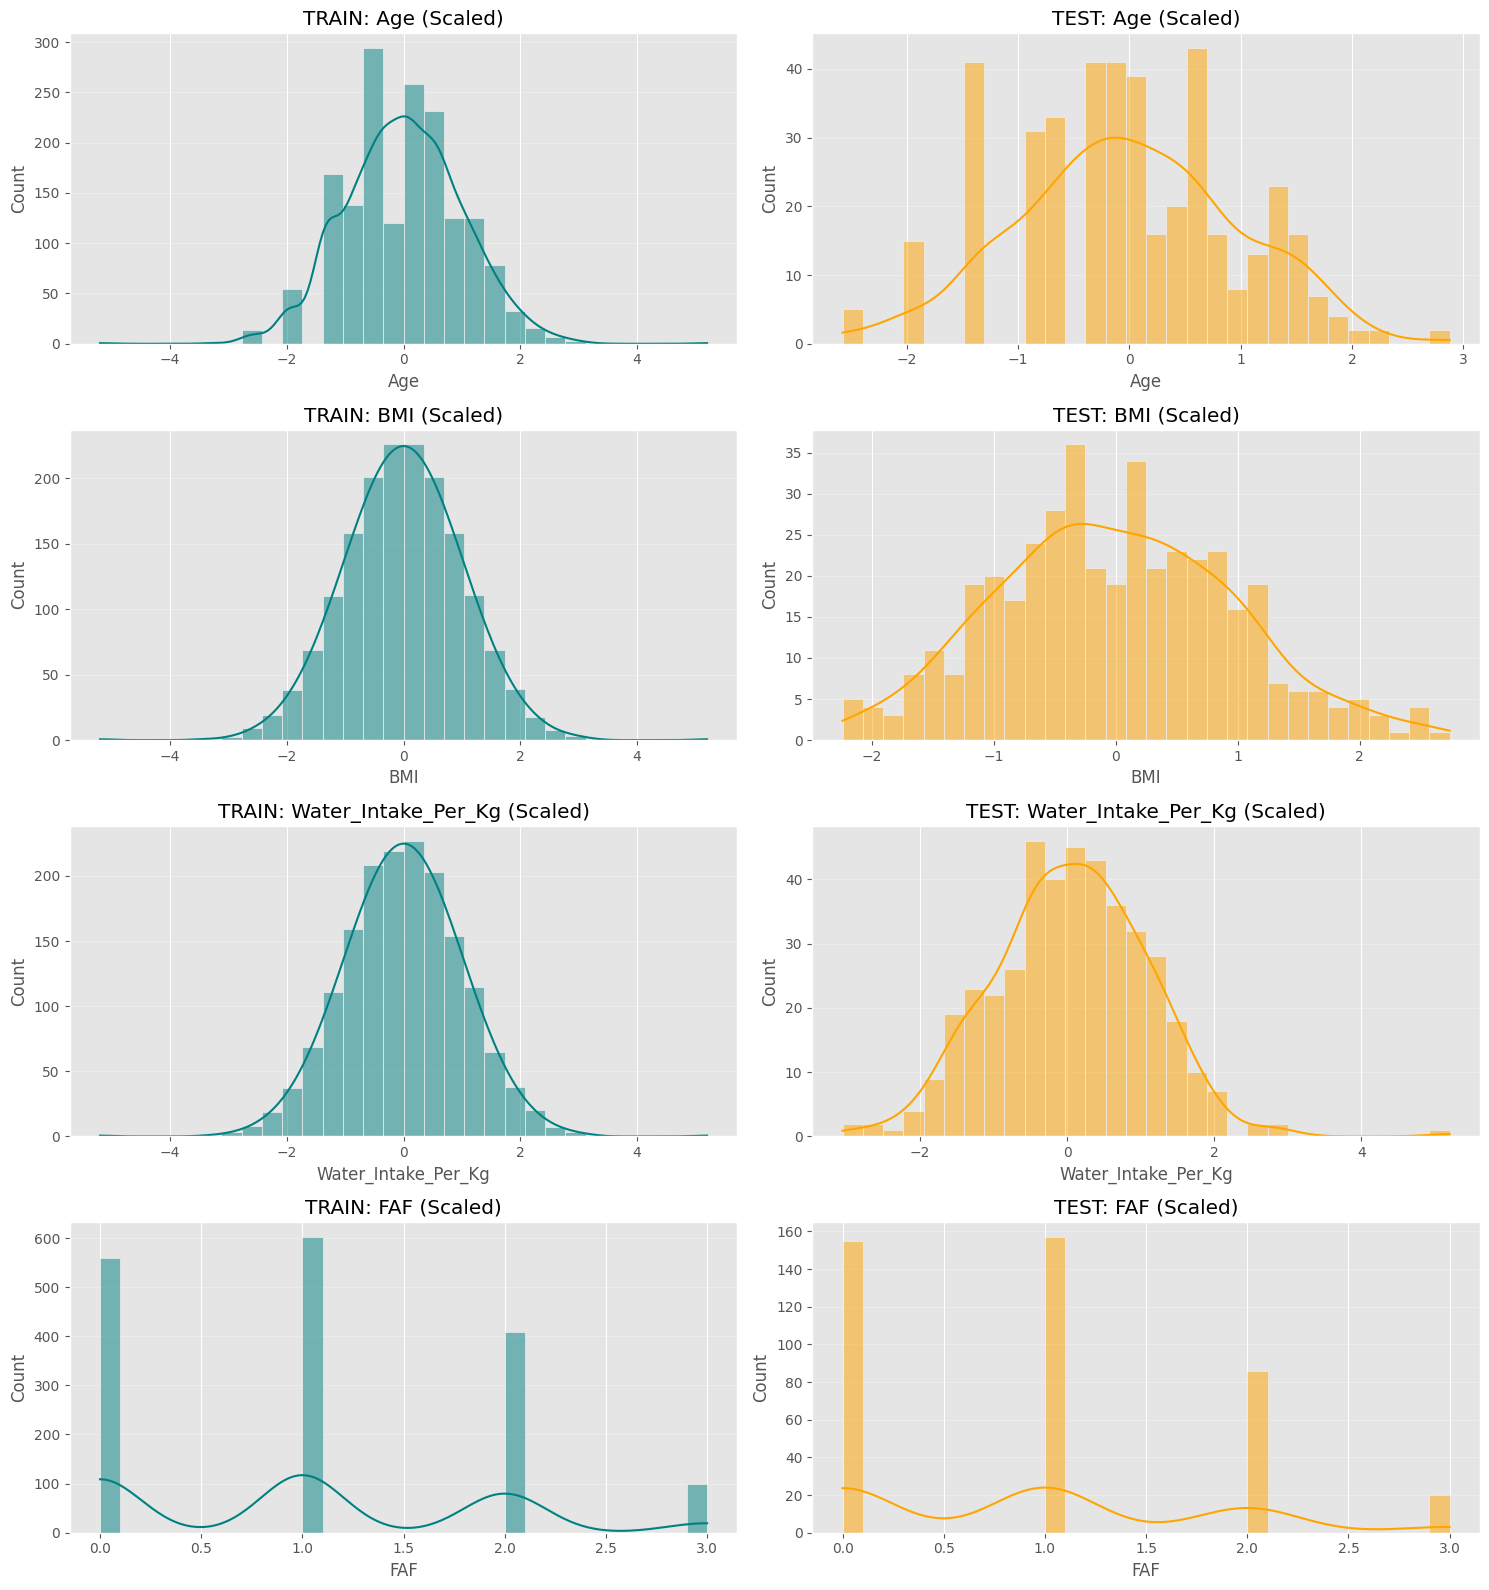

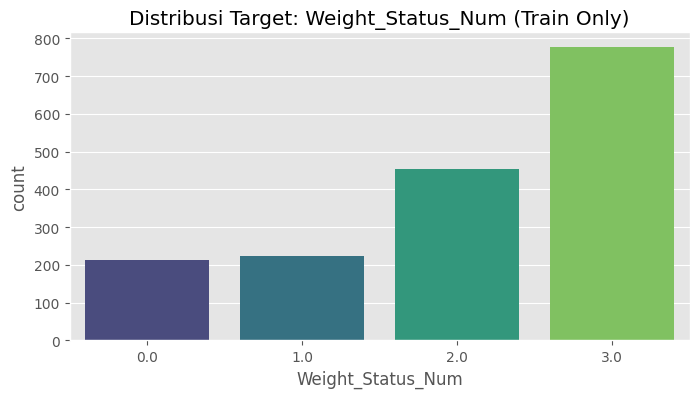

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# 1. Tentukan list fitur yang di-scale + target (khusus di train)
features_to_plot = ['Age', 'BMI', 'Water_Intake_Per_Kg', 'FAF']
target_col = 'Weight_Status_Num'

# 2. Pengaturan Grid (Baris disesuaikan dengan jumlah fitur)
n_cols = 2 # Kolom kiri untuk Train, Kolom kanan untuk Test
n_rows = len(features_to_plot)

plt.figure(figsize=(15, n_rows * 4))

for i, col in enumerate(features_to_plot):
    # --- PLOT DATA TRAIN (KIRI) ---
    plt.subplot(n_rows, n_cols, 2*i + 1)
    sns.histplot(df_train_scaled[col], kde=True, color='teal', bins=30)
    plt.title(f'TRAIN: {col} (Scaled)')
    plt.grid(axis='y', alpha=0.3)

    # --- PLOT DATA TEST (KANAN) ---
    plt.subplot(n_rows, n_cols, 2*i + 2)
    sns.histplot(df_test_scaled[col], kde=True, color='orange', bins=30)
    plt.title(f'TEST: {col} (Scaled)')
    plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# 3. Khusus Visualisasi Target (Hanya ada di Train)
plt.figure(figsize=(8, 4))
sns.countplot(x=df_train_scaled[target_col], palette='viridis')
plt.title(f'Distribusi Target: {target_col} (Train Only)')
plt.show()

*Save data hasil scaling dalam format csv*

In [44]:
# Simpan Data Train yang sudah di-scale
df_train_scaled.to_csv('df_train_scaled.csv', index=False)

# Simpan Data Test yang sudah di-scale
df_test_scaled.to_csv('df_test_scaled.csv', index=False)

print("✅ File CSV berhasil disimpan!")

✅ File CSV berhasil disimpan!


## Modeling

### Persiapan Data untuk Modeling

In [45]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score
import joblib
import warnings
warnings.filterwarnings('ignore')

# Pisahkan fitur (X) dan target (y) dari df_train_scaled
feature_cols = [
    'Age', 'BMI', 'Water_Intake_Per_Kg', 'FAF',
    'Gender_Num', 'family_history_with_overweight_Num',
    'CAEC_Num', 'FAVC_Num', 'SCC_Num'
]

X_train = df_train_scaled[feature_cols]
y_train = df_train_scaled['Weight_Status_Num'].astype(int)

X_test = df_test_scaled[feature_cols]

print(f"X_train shape : {X_train.shape}")
print(f"y_train shape : {y_train.shape}")
print(f"X_test shape  : {X_test.shape}")
print(f"Fitur         : {feature_cols}")
print(f"Kelas target  : {sorted(y_train.unique())}")

X_train shape : (1669, 9)
y_train shape : (1669,)
X_test shape  : (418, 9)
Fitur         : ['Age', 'BMI', 'Water_Intake_Per_Kg', 'FAF', 'Gender_Num', 'family_history_with_overweight_Num', 'CAEC_Num', 'FAVC_Num', 'SCC_Num']
Kelas target  : [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]


### Training Semua Algoritma

In [46]:
# Definisi semua model yang akan diuji
models = {
    'Logistic Regression'     : LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree'           : DecisionTreeClassifier(random_state=42),
    'Random Forest'           : RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting'       : GradientBoostingClassifier(n_estimators=100, random_state=42),
    'SVM'                     : SVC(kernel='rbf', probability=True, random_state=42),
    'K-Nearest Neighbors'     : KNeighborsClassifier(n_neighbors=5),
    'Naive Bayes'             : GaussianNB(),
}

results = {}

print("=" * 65)
print(f"{'Model':<30} {'CV Accuracy':>12} {'Std Dev':>10}")
print("=" * 65)

for name, model in models.items():
    # 5-Fold Cross Validation pada data train
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    results[name] = {
        'model'    : model,
        'cv_mean'  : cv_scores.mean(),
        'cv_std'   : cv_scores.std(),
    }
    print(f"{name:<30} {cv_scores.mean():>12.4f} {cv_scores.std():>10.4f}")

print("=" * 65)

Model                           CV Accuracy    Std Dev
Logistic Regression                  0.9521     0.0162
Decision Tree                        0.9886     0.0052
Random Forest                        0.9940     0.0038
Gradient Boosting                    0.9898     0.0056
SVM                                  0.9521     0.0101
K-Nearest Neighbors                  0.8802     0.0174
Naive Bayes                          0.7579     0.0213


### Pemilihan Model Terbaik


🏆 RANKING MODEL BERDASARKAN CV ACCURACY:
--------------------------------------------------
⭐ #1 Random Forest                → 0.9940 ± 0.0038
   #2 Gradient Boosting            → 0.9898 ± 0.0056
   #3 Decision Tree                → 0.9886 ± 0.0052
   #4 SVM                          → 0.9521 ± 0.0101
   #5 Logistic Regression          → 0.9521 ± 0.0162
   #6 K-Nearest Neighbors          → 0.8802 ± 0.0174
   #7 Naive Bayes                  → 0.7579 ± 0.0213

✅ Model Terbaik: Random Forest


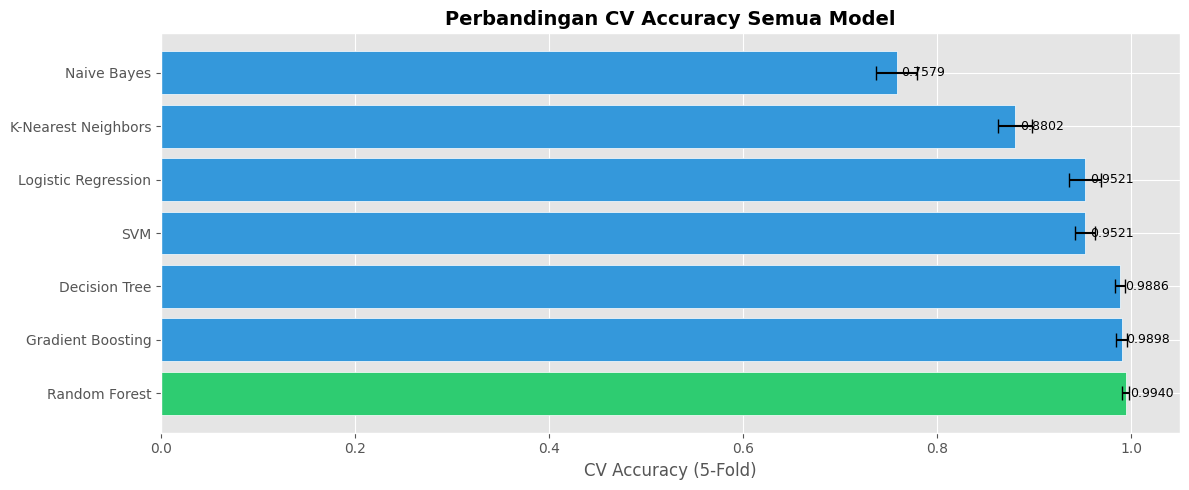

In [47]:
import matplotlib.pyplot as plt

# Urutkan berdasarkan CV accuracy tertinggi
sorted_results = sorted(results.items(), key=lambda x: x[1]['cv_mean'], reverse=True)

print("\n🏆 RANKING MODEL BERDASARKAN CV ACCURACY:")
print("-" * 50)
for rank, (name, info) in enumerate(sorted_results, 1):
    marker = "⭐" if rank == 1 else "  "
    print(f"{marker} #{rank} {name:<28} → {info['cv_mean']:.4f} ± {info['cv_std']:.4f}")

best_model_name = sorted_results[0][0]
best_model_obj  = sorted_results[0][1]['model']
print(f"\n✅ Model Terbaik: {best_model_name}")

# Visualisasi perbandingan CV accuracy
names  = [r[0] for r in sorted_results]
means  = [r[1]['cv_mean'] for r in sorted_results]
stds   = [r[1]['cv_std']  for r in sorted_results]

colors = ['#2ecc71' if n == best_model_name else '#3498db' for n in names]

plt.figure(figsize=(12, 5))
bars = plt.barh(names, means, xerr=stds, color=colors, edgecolor='white', capsize=5)
plt.xlabel('CV Accuracy (5-Fold)', fontsize=12)
plt.title('Perbandingan CV Accuracy Semua Model', fontsize=14, fontweight='bold')
plt.xlim(0, 1.05)
for bar, mean in zip(bars, means):
    plt.text(mean + 0.005, bar.get_y() + bar.get_height()/2,
             f'{mean:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

### Final Training & Simpan Model Terbaik

In [48]:
# Latih model terbaik menggunakan SELURUH data train
best_model_obj.fit(X_train, y_train)

# Prediksi pada data train (in-sample check)
y_pred_train = best_model_obj.predict(X_train)
train_acc = accuracy_score(y_train, y_pred_train)

print(f"Model         : {best_model_name}")
print(f"Train Accuracy: {train_acc:.4f}")

# Simpan model terbaik
joblib.dump(best_model_obj, 'model_obesitas.pkl')
print(f"\n✅ Model '{best_model_name}' berhasil disimpan sebagai 'model_obesitas.pkl'")

Model         : Random Forest
Train Accuracy: 1.0000

✅ Model 'Random Forest' berhasil disimpan sebagai 'model_obesitas.pkl'


## Model Evaluation

In [49]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Mapping label numerik ke nama kelas
label_map = {
    0: 'Underweight',
    1: 'Normal',
    2: 'Overweight',
    3: 'Obese'
}

y_pred = best_model_obj.predict(X_train)
y_true_labels = [label_map[v] for v in y_train]
y_pred_labels = [label_map[v] for v in y_pred]

print("=" * 60)
print(f"EVALUASI MODEL: {best_model_name}")
print("=" * 60)
print(f"Train Accuracy : {accuracy_score(y_train, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_true_labels, y_pred_labels))

EVALUASI MODEL: Random Forest
Train Accuracy : 1.0000

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       225
       Obese       1.00      1.00      1.00       777
  Overweight       1.00      1.00      1.00       453
 Underweight       1.00      1.00      1.00       214

    accuracy                           1.00      1669
   macro avg       1.00      1.00      1.00      1669
weighted avg       1.00      1.00      1.00      1669



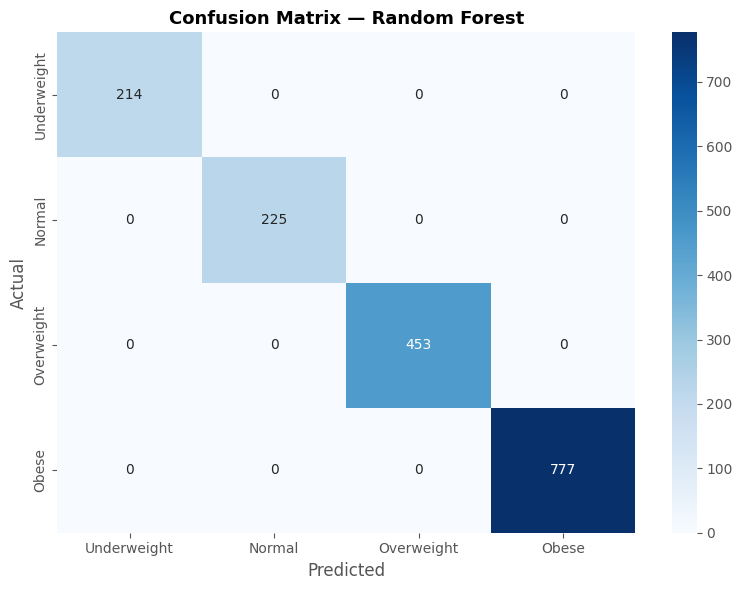

In [50]:
# Confusion Matrix
class_names = ['Underweight', 'Normal', 'Overweight', 'Obese']
cm = confusion_matrix(y_train, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title(f'Confusion Matrix — {best_model_name}', fontsize=13, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [51]:
from sklearn.model_selection import StratifiedKFold

# Detail Cross Validation model terbaik
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_detail = cross_val_score(best_model_obj, X_train, y_train, cv=skf, scoring='accuracy')

print(f"Detail 5-Fold CV — {best_model_name}")
print("-" * 40)
for i, score in enumerate(cv_detail, 1):
    print(f"  Fold {i}: {score:.4f}")
print("-" * 40)
print(f"  Mean : {cv_detail.mean():.4f}")
print(f"  Std  : {cv_detail.std():.4f}")

Detail 5-Fold CV — Random Forest
----------------------------------------
  Fold 1: 0.9910
  Fold 2: 0.9880
  Fold 3: 0.9970
  Fold 4: 0.9910
  Fold 5: 0.9910
----------------------------------------
  Mean : 0.9916
  Std  : 0.0029


## Deep Learning (TensorFlow / Keras)

Setelah mendapatkan model terbaik dari ML klasik, kita latih juga Deep Neural Network menggunakan TensorFlow sebagai pembanding dan kandidat model produksi.

### Persiapan TensorFlow & Konversi Label

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib
import warnings
warnings.filterwarnings('ignore')

# Pastikan reproducibility
tf.random.set_seed(42)
np.random.seed(42)

print(f"TensorFlow version : {tf.__version__}")
print(f"Keras version      : {keras.__version__}")
print(f"X_train shape      : {X_train.shape}")
print(f"y_train shape      : {y_train.shape}")
print(f"Jumlah Kelas       : {len(np.unique(y_train))}")


### One-Hot Encoding Target untuk DL

In [ ]:
from tensorflow.keras.utils import to_categorical

# Konversi label integer → one-hot (4 kelas: 0,1,2,3)
num_classes = 4
y_train_cat = to_categorical(y_train.values, num_classes=num_classes)

print(f"y_train (original) sample : {y_train.values[:5]}")
print(f"y_train_cat sample        :")
print(y_train_cat[:5])
print(f"Shape y_train_cat         : {y_train_cat.shape}")


### Arsitektur Model Deep Neural Network

In [ ]:
def build_dnn_model(input_dim, num_classes=4, dropout_rate=0.3, learning_rate=0.001):
    """
    Deep Neural Network untuk klasifikasi obesitas.
    - 3 hidden layers dengan BatchNormalization + Dropout
    - Aktivasi ReLU untuk hidden, Softmax untuk output
    """
    model = keras.Sequential([
        # Input Layer
        layers.Input(shape=(input_dim,), name='input'),

        # Hidden Layer 1
        layers.Dense(128, name='dense_1'),
        layers.BatchNormalization(name='bn_1'),
        layers.Activation('relu', name='relu_1'),
        layers.Dropout(dropout_rate, name='dropout_1'),

        # Hidden Layer 2
        layers.Dense(64, name='dense_2'),
        layers.BatchNormalization(name='bn_2'),
        layers.Activation('relu', name='relu_2'),
        layers.Dropout(dropout_rate, name='dropout_2'),

        # Hidden Layer 3
        layers.Dense(32, name='dense_3'),
        layers.BatchNormalization(name='bn_3'),
        layers.Activation('relu', name='relu_3'),
        layers.Dropout(dropout_rate / 2, name='dropout_3'),

        # Output Layer (Softmax untuk multi-class)
        layers.Dense(num_classes, activation='softmax', name='output')
    ], name='DNN_Obesitas')

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# Build model
dnn_model = build_dnn_model(input_dim=X_train.shape[1], num_classes=num_classes)
dnn_model.summary()


### Training DNN dengan Callbacks

In [ ]:
from sklearn.model_selection import train_test_split as sk_split

# Bagi X_train → train DL (80%) + validation DL (20%)
X_tr_dl, X_val_dl, y_tr_dl, y_val_dl = sk_split(
    X_train.values, y_train_cat,
    test_size=0.2, random_state=42, stratify=y_train.values
)

print(f"DL Train set  : {X_tr_dl.shape}")
print(f"DL Val set    : {X_val_dl.shape}")

# Callbacks
cb_early_stop = callbacks.EarlyStopping(
    monitor='val_loss', patience=15, restore_best_weights=True, verbose=1
)
cb_reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=7, min_lr=1e-6, verbose=1
)
cb_checkpoint = callbacks.ModelCheckpoint(
    'best_dnn_model.keras', monitor='val_accuracy',
    save_best_only=True, verbose=0
)

# Training
history = dnn_model.fit(
    X_tr_dl, y_tr_dl,
    validation_data=(X_val_dl, y_val_dl),
    epochs=150,
    batch_size=32,
    callbacks=[cb_early_stop, cb_reduce_lr, cb_checkpoint],
    verbose=1
)

print("\n✅ Training DNN selesai!")


### Visualisasi Learning Curve DNN

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss Curve
axes[0].plot(history.history['loss'], label='Train Loss', color='#3498db')
axes[0].plot(history.history['val_loss'], label='Val Loss', color='#e74c3c')
axes[0].set_title('Loss Curve — DNN', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Categorical Crossentropy')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Accuracy Curve
axes[1].plot(history.history['accuracy'], label='Train Acc', color='#2ecc71')
axes[1].plot(history.history['val_accuracy'], label='Val Acc', color='#e67e22')
axes[1].set_title('Accuracy Curve — DNN', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Best Val Accuracy : {max(history.history['val_accuracy']):.4f}")
print(f"Final Train Acc   : {history.history['accuracy'][-1]:.4f}")


### Evaluasi DNN pada Data Training

In [ ]:
label_map_dl = {0: 'Underweight', 1: 'Normal', 2: 'Overweight', 3: 'Obese'}
class_names_dl = ['Underweight', 'Normal', 'Overweight', 'Obese']

# Prediksi pada seluruh X_train
y_pred_dnn_proba = dnn_model.predict(X_train.values, verbose=0)
y_pred_dnn = np.argmax(y_pred_dnn_proba, axis=1)

# Akurasi
dnn_train_acc = accuracy_score(y_train.values, y_pred_dnn)

print("=" * 60)
print("EVALUASI DNN — DATA TRAINING")
print("=" * 60)
print(f"Train Accuracy : {dnn_train_acc:.4f}")
print()
print("Classification Report:")
y_true_labels_dl = [label_map_dl[v] for v in y_train.values]
y_pred_labels_dl = [label_map_dl[v] for v in y_pred_dnn]
print(classification_report(y_true_labels_dl, y_pred_labels_dl, target_names=class_names_dl))


In [ ]:
# Confusion Matrix DNN
cm_dnn = confusion_matrix(y_train.values, y_pred_dnn)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_dnn, annot=True, fmt='d', cmap='Purples',
            xticklabels=class_names_dl, yticklabels=class_names_dl)
plt.title('Confusion Matrix — DNN (TensorFlow)', fontsize=13, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()


### Perbandingan DNN vs Model ML Terbaik

In [ ]:
# Ambil CV accuracy model ML terbaik
best_ml_cv = results[best_model_name]['cv_mean']
best_ml_std = results[best_model_name]['cv_std']

# DNN val accuracy terbaik
dnn_best_val = max(history.history['val_accuracy'])
dnn_train_acc_final = history.history['accuracy'][-1]

print("=" * 65)
print(f"{'Metrik':<35} {'ML Terbaik':>12} {'DNN':>12}")
print("=" * 65)
print(f"{'CV / Val Accuracy':<35} {best_ml_cv:>12.4f} {dnn_best_val:>12.4f}")
print(f"{'Train Accuracy':<35} {accuracy_score(y_train, best_model_obj.predict(X_train)):>12.4f} {dnn_train_acc:>12.4f}")
print("=" * 65)
print(f"\nModel ML Terbaik : {best_model_name}")
print(f"DNN Best Val Acc : {dnn_best_val:.4f}")

# Tentukan model yang akan digunakan di API
if dnn_best_val >= best_ml_cv:
    api_model_type = 'dnn'
    print("\n🏆 DNN dipilih sebagai model produksi (val_accuracy lebih tinggi atau setara)")
else:
    api_model_type = 'ml'
    print(f"\n🏆 {best_model_name} dipilih sebagai model produksi (CV accuracy lebih tinggi)")


### Simpan DNN Model & Semua Artefak

In [ ]:
import os

# 1. Simpan DNN dalam format SavedModel (TF native) & H5
dnn_model.save('model_dnn_obesitas.keras')
dnn_model.save('model_dnn_obesitas.h5')

# 2. Simpan ML model (sudah disimpan sebelumnya, verifikasi ulang)
joblib.dump(best_model_obj, 'model_obesitas.pkl')

# 3. Scaler sudah disimpan, verifikasi
joblib.dump(scaler, 'scaler_obesitas.pkl')

# 4. Simpan metadata model DNN
import json as _json
dnn_metadata = {
    'model_name'    : 'DNN_Obesitas',
    'input_features': feature_cols,
    'num_classes'   : num_classes,
    'label_map'     : {str(k): v for k, v in label_map_dl.items()},
    'cols_to_scale' : columns_to_scale,
    'best_val_acc'  : round(float(dnn_best_val), 4),
    'api_model_type': api_model_type
}
with open('dnn_metadata.json', 'w') as f:
    _json.dump(dnn_metadata, f, indent=2)

# 5. Verifikasi semua file
required_files = [
    'ObesityDataSet_raw_and_data_sinthetic.csv',
    'df_train_scaled.csv',
    'df_test_scaled.csv',
    'scaler_obesitas.pkl',
    'model_obesitas.pkl',
    'model_dnn_obesitas.keras',
    'model_dnn_obesitas.h5',
    'best_dnn_model.keras',
    'dnn_metadata.json',
]

print("✅ STATUS FILE ARTEFAK:")
print("-" * 45)
for f in required_files:
    status = "✅ ADA" if os.path.exists(f) else "❌ TIDAK ADA"
    size   = f"({os.path.getsize(f)/1024:.1f} KB)" if os.path.exists(f) else ""
    print(f"  {status}  {f} {size}")


## Flask API (Mendukung ML & DNN)

Cell ini membuat `app.py` yang mendukung dua mode prediksi: model ML klasik (`model_obesitas.pkl`) dan model DNN TensorFlow (`model_dnn_obesitas.keras`). Default menggunakan model dengan performa terbaik.

In [ ]:
flask_code = '''
from flask import Flask, request, jsonify
import joblib
import numpy as np
import pandas as pd
import json
import os

app = Flask(__name__)

# ─── LOAD ARTEFAK ────────────────────────────────────────────────────

# Scaler (wajib ada)
scaler = joblib.load('scaler_obesitas.pkl')

# Load metadata DNN
with open('dnn_metadata.json', 'r') as f:
    dnn_meta = json.load(f)

# Pilih model berdasarkan metadata
API_MODEL_TYPE = dnn_meta.get('api_model_type', 'ml')

if API_MODEL_TYPE == 'dnn':
    import tensorflow as tf
    dnn_model = tf.keras.models.load_model('model_dnn_obesitas.keras')
    ml_model  = None
    print("[API] Menggunakan model: DNN (TensorFlow)")
else:
    ml_model  = joblib.load('model_obesitas.pkl')
    dnn_model = None
    print("[API] Menggunakan model: ML Klasik")

# Konfigurasi fitur
FEATURE_COLS  = dnn_meta['input_features']
COLS_TO_SCALE = dnn_meta['cols_to_scale']
LABEL_MAP     = {int(k): v for k, v in dnn_meta['label_map'].items()}

# ─── HELPER ──────────────────────────────────────────────────────────

def preprocess(data: dict) -> pd.DataFrame:
    """Validasi, buat DataFrame, dan scale fitur kontinu."""
    missing = [f for f in FEATURE_COLS if f not in data]
    if missing:
        raise ValueError(f"Fitur tidak ditemukan: {missing}")
    df_in = pd.DataFrame([data])[FEATURE_COLS]
    df_in[COLS_TO_SCALE] = scaler.transform(df_in[COLS_TO_SCALE])
    return df_in


def predict_ml(df_in: pd.DataFrame) -> dict:
    pred_num   = int(ml_model.predict(df_in)[0])
    pred_label = LABEL_MAP.get(pred_num, 'Unknown')
    proba_dict = {}
    if hasattr(ml_model, 'predict_proba'):
        proba = ml_model.predict_proba(df_in)[0]
        proba_dict = {LABEL_MAP[i]: round(float(p), 4) for i, p in enumerate(proba)}
    return {'prediction': pred_label, 'prediction_id': pred_num,
            'probabilities': proba_dict, 'model_used': 'ML'}


def predict_dnn(df_in: pd.DataFrame) -> dict:
    proba = dnn_model.predict(df_in.values, verbose=0)[0]
    pred_num   = int(np.argmax(proba))
    pred_label = LABEL_MAP.get(pred_num, 'Unknown')
    proba_dict = {LABEL_MAP[i]: round(float(p), 4) for i, p in enumerate(proba)}
    return {'prediction': pred_label, 'prediction_id': pred_num,
            'probabilities': proba_dict, 'model_used': 'DNN'}

# ─── ENDPOINTS ───────────────────────────────────────────────────────

@app.route('/', methods=['GET'])
def index():
    return jsonify({
        'status'      : 'OK',
        'message'     : 'Obesity Classification API',
        'model_active': API_MODEL_TYPE.upper(),
        'endpoints'   : {
            'predict'     : 'POST /predict',
            'predict_ml'  : 'POST /predict/ml  (paksa ML model)',
            'predict_dnn' : 'POST /predict/dnn (paksa DNN model)',
            'health'      : 'GET  /health',
            'features'    : 'GET  /features'
        }
    })


@app.route('/health', methods=['GET'])
def health():
    return jsonify({'status': 'sehat', 'model_active': API_MODEL_TYPE})


@app.route('/features', methods=['GET'])
def features():
    return jsonify({
        'features'     : FEATURE_COLS,
        'cols_to_scale': COLS_TO_SCALE,
        'label_map'    : LABEL_MAP,
        'description'  : {
            'Age'                               : 'Usia (tahun)',
            'BMI'                               : 'Body Mass Index (kg/m2)',
            'Water_Intake_Per_Kg'               : 'Asupan air per kg berat badan',
            'FAF'                               : 'Frekuensi aktivitas fisik (0-3)',
            'Gender_Num'                        : '0=Male, 1=Female',
            'family_history_with_overweight_Num': '0=Tidak, 1=Ya',
            'CAEC_Num'                          : '0=no, 1=Sometimes, 2=Frequently, 3=Always',
            'FAVC_Num'                          : '0=no, 1=yes (konsumsi makanan tinggi kalori)',
            'SCC_Num'                           : '0=no, 1=yes (monitoring kalori)'
        }
    })


@app.route('/predict', methods=['POST'])
def predict():
    """Prediksi dengan model aktif (default dari metadata)."""
    try:
        data   = request.get_json(force=True)
        df_in  = preprocess(data)
        result = predict_dnn(df_in) if API_MODEL_TYPE == 'dnn' else predict_ml(df_in)
        return jsonify(result)
    except ValueError as e:
        return jsonify({'error': str(e)}), 400
    except Exception as e:
        return jsonify({'error': str(e)}), 500


@app.route('/predict/ml', methods=['POST'])
def predict_ml_endpoint():
    """Paksa prediksi dengan ML model."""
    if ml_model is None:
        # Lazy-load ML model
        import joblib as jl
        _ml = jl.load('model_obesitas.pkl')
    else:
        _ml = ml_model
    try:
        data  = request.get_json(force=True)
        df_in = preprocess(data)
        pred_num   = int(_ml.predict(df_in)[0])
        pred_label = LABEL_MAP.get(pred_num, 'Unknown')
        proba_dict = {}
        if hasattr(_ml, 'predict_proba'):
            proba = _ml.predict_proba(df_in)[0]
            proba_dict = {LABEL_MAP[i]: round(float(p), 4) for i, p in enumerate(proba)}
        return jsonify({'prediction': pred_label, 'prediction_id': pred_num,
                        'probabilities': proba_dict, 'model_used': 'ML'})
    except ValueError as e:
        return jsonify({'error': str(e)}), 400
    except Exception as e:
        return jsonify({'error': str(e)}), 500


@app.route('/predict/dnn', methods=['POST'])
def predict_dnn_endpoint():
    """Paksa prediksi dengan DNN (TensorFlow)."""
    if dnn_model is None:
        import tensorflow as tf
        _dnn = tf.keras.models.load_model('model_dnn_obesitas.keras')
    else:
        _dnn = dnn_model
    try:
        data  = request.get_json(force=True)
        df_in = preprocess(data)
        proba = _dnn.predict(df_in.values, verbose=0)[0]
        pred_num   = int(np.argmax(proba))
        pred_label = LABEL_MAP.get(pred_num, 'Unknown')
        proba_dict = {LABEL_MAP[i]: round(float(p), 4) for i, p in enumerate(proba)}
        return jsonify({'prediction': pred_label, 'prediction_id': pred_num,
                        'probabilities': proba_dict, 'model_used': 'DNN'})
    except ValueError as e:
        return jsonify({'error': str(e)}), 400
    except Exception as e:
        return jsonify({'error': str(e)}), 500


if __name__ == '__main__':
    app.run(debug=True, host='0.0.0.0', port=5000)
'''

with open('app.py', 'w') as f:
    f.write(flask_code.strip())

print("✅ Flask API berhasil disimpan sebagai 'app.py'")
print()
print("Cara menjalankan:")
print("  pip install flask tensorflow scikit-learn joblib pandas numpy")
print("  python app.py")
print()
print("Endpoint yang tersedia:")
print("  GET  /             → Info API")
print("  GET  /health       → Status API")
print("  GET  /features     → Daftar fitur & keterangan")
print("  POST /predict      → Prediksi (model aktif)")
print("  POST /predict/ml   → Paksa prediksi ML")
print("  POST /predict/dnn  → Paksa prediksi DNN")
print()
print("Contoh request (cURL):")
print("""  curl -X POST http://localhost:5000/predict \\
       -H 'Content-Type: application/json' \\
       -d '{
         "Age": 28, "BMI": 27.5, "Water_Intake_Per_Kg": 0.03,
         "FAF": 1, "Gender_Num": 0,
         "family_history_with_overweight_Num": 1,
         "CAEC_Num": 1, "FAVC_Num": 1, "SCC_Num": 0
       }'""")


### Ringkasan File yang Dihasilkan

In [ ]:
import os

print("=" * 55)
print("📁 DAFTAR FILE PENTING YANG DIHASILKAN")
print("=" * 55)

file_info = {
    'ObesityDataSet_raw_and_data_sinthetic.csv' : 'Dataset utama (raw)',
    'df_train_scaled.csv'                        : 'Data train (9 fitur + 1 target, scaled)',
    'df_test_scaled.csv'                         : 'Data test (9 fitur, scaled)',
    'scaler_obesitas.pkl'                        : 'QuantileTransformer scaler',
    'model_obesitas.pkl'                         : 'Model ML terbaik (sklearn)',
    'model_dnn_obesitas.keras'                   : 'Model DNN TensorFlow (.keras)',
    'model_dnn_obesitas.h5'                      : 'Model DNN TensorFlow (.h5)',
    'best_dnn_model.keras'                       : 'Checkpoint DNN terbaik (val_acc)',
    'dnn_metadata.json'                          : 'Metadata model & konfigurasi API',
    'app.py'                                     : 'Flask REST API',
}

for fname, desc in file_info.items():
    exists = os.path.exists(fname)
    icon   = '✅' if exists else '⚠️ '
    size   = f"({os.path.getsize(fname)/1024:.1f} KB)" if exists else "(belum ada — jalankan notebook dulu)"
    print(f"{icon} {fname}")
    print(f"   └─ {desc} {size}")
    print()


---

> **Catatan:** File `ObesityDataSet_raw_and_data_sinthetic.csv` harus berada di direktori yang sama saat notebook dijalankan. Seluruh file output (`df_train_scaled.csv`, `df_test_scaled.csv`, `scaler_obesitas.pkl`, `model_*.pkl/keras/h5`, `dnn_metadata.json`, `app.py`) akan ter-generate otomatis setelah notebook dijalankan penuh.